In [1]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata
import os
from collections import Counter
from sklearn.decomposition import PCA


#ploting modules
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import anndata
from scipy import stats
import warnings
import logging


working_dic="/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/GSEA cell death/M_polarization/"
os.chdir(working_dic)

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.logging.print_version_and_date()
sc.settings.set_figure_params(dpi=100, color_map='RdBu_r')

sc.settings.verbosity = 1
warnings.filterwarnings('ignore')

# If you're using libraries like pandas, you can also set their display options
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', None)

Matplotlib created a temporary cache directory at /tmp/matplotlib-yui1n_dr because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


scanpy==1.10.2 anndata==0.10.8 umap==0.5.6 numpy==1.24.4 scipy==1.11.3 pandas==2.2.3 scikit-learn==1.3.1 statsmodels==0.14.0 igraph==0.11.6 pynndescent==0.5.13
Running Scanpy 1.10.2, on 2026-01-08 14:34.


In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
dimplot_color=mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["#E5E5E5","#FF0000"])

In [3]:
global_adata = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/cellchat preparation/Merging UMIs/CC_prepared_global_adata_raw_without_lognorm.h5ad')

In [4]:
global_adata

AnnData object with n_obs × n_vars = 211317 × 40653
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions'
    uns: 'Sample_ID_colors', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap'

In [5]:
# Step 3: Normalize and log-transform
sc.pp.normalize_total(global_adata, target_sum=1e4)
sc.pp.log1p(global_adata)


# XXXXXXXX

In [7]:
## Subset for Myeloids from baboon with specific conditions
#myeloid_baboon_adata = global_adata[
#    (global_adata.obs['cell_type'] == 'Myeloids (baboon)') &
#    (global_adata.obs['Conditions'].isin(['Rejection', 'Per protocol']))
#].copy()
#
## Verify the subset
#print(f"Subset shape: {myeloid_baboon_adata.shape}")
#print("Conditions in subset:", myeloid_baboon_adata.obs['Conditions'].unique().tolist())


In [6]:
# Ensure it's a pandas Series
obs = global_adata.obs

# Make sure 'Condition_subsets' is categorical with all needed categories
if 'Condition_subsets' not in obs.columns:
    obs['Condition_subsets'] = obs['Conditions'].astype('category')
else:
    obs['Condition_subsets'] = obs['Condition_subsets'].astype('category')

# Add new categories if not present
for cat in ['Extended protocol', 'Standard protocol']:
    if cat not in obs['Condition_subsets'].cat.categories:
        obs['Condition_subsets'] = obs['Condition_subsets'].cat.add_categories([cat])

# Now assign as you intended
obs.loc[
    (obs['Conditions'] == 'Per protocol') & (obs['Sample_ID'].isin(['PAV71', 'PAV72', 'PAV85'])),
    'Condition_subsets'
] = 'Extended protocol'

obs.loc[
    (obs['Conditions'] == 'Per protocol') & (~obs['Sample_ID'].isin(['PAV71', 'PAV72', 'PAV85'])),
    'Condition_subsets'
] = 'Standard protocol'

# Optional: drop unused categories
obs['Condition_subsets'] = obs['Condition_subsets'].cat.remove_unused_categories()

# Done!
print(obs['Condition_subsets'].value_counts())

Condition_subsets
Standard protocol         70411
Rejection                 39715
Control                   39248
Extended protocol         25352
Prematurely terminated    18957
PCMV                      17634
Name: count, dtype: int64


In [9]:
global_adata

AnnData object with n_obs × n_vars = 211317 × 40653
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets'
    uns: 'Sample_ID_colors', 'cell_type_colors', 'log1p'
    obsm: 'X_pca', 'X_umap'

In [7]:
global_adata.obs['cell_type'].unique().tolist()

['CM',
 'Fibroblasts',
 'vascular EC',
 'Endocardial/lymphatic EC',
 'Myeloids (baboon)',
 'Mural cells',
 'Neuronal cells',
 'Lymphoids (baboon)',
 'Endothelial cells (baboon)',
 'Resident Immune',
 'Mast cells (baboon)']

In [8]:
# Define the cell types you want to keep
desired_cell_types = ['Myeloids (baboon)', 'Resident Immune']

# Subset the AnnData object
subset_adata = global_adata[global_adata.obs['cell_type'].isin(desired_cell_types)]

# (Optional) Verify the unique cell types in your subset
print(subset_adata.obs['cell_type'].unique().tolist())
# Print the unique condition subsets in the subset
print("Condition_subsets in subset:", subset_adata.obs['Condition_subsets'].unique().tolist())

['Myeloids (baboon)', 'Resident Immune']
Condition_subsets in subset: ['Standard protocol', 'Rejection', 'Extended protocol', 'PCMV', 'Prematurely terminated', 'Control']


In [9]:
subset_adata

View of AnnData object with n_obs × n_vars = 14744 × 40653
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets'
    uns: 'Sample_ID_colors', 'log1p'
    obsm: 'X_pca', 'X_umap'

In [10]:
# Define the cell types to keep
desired_cell_types = [
    'MP_LYVE1hi_2.0_sus',
    'MP_LYVE1hi_1.0_sus',
    'MP_groundstate_sus',
    'MP_SPP1_sus',
    'MP_ISG_sus',
    'MP_NFkB_sus',
    'MP_TREM2_sus',
    'MP_pCMVpos_sus',
    'MP_GBE1_papio',
    'MP_ISG_papio',
    'MP_LYVE1hi_papio',
    'MP_LYVE1lo_papio',
    'MP_NFkB_papio',
    'MP_TREM2_papio',
    'MP_groundstate_papio',
    'Prolif_Myeloids_papio',
    'Unclassified'
]

# Define the conditions to exclude
excluded_conditions = ['PCMV', 'Prematurely terminated']

# Subset the AnnData object
adata_mac = subset_adata[
    subset_adata.obs['cell_states'].isin(desired_cell_types) &
    ~subset_adata.obs['Condition_subsets'].isin(excluded_conditions)
]

# Verify the results
print("Subset shape:", adata_mac.shape)
print("Cell types in subset:", adata_mac.obs['cell_states'].unique().tolist())
print("Condition_subsets in subset:", adata_mac.obs['Condition_subsets'].unique().tolist())


Subset shape: (10238, 40653)
Cell types in subset: ['MP_LYVE1hi_papio', 'MP_ISG_papio', 'MP_LYVE1lo_papio', 'MP_TREM2_papio', 'MP_GBE1_papio', 'Unclassified', 'MP_groundstate_papio', 'Prolif_Myeloids_papio', 'MP_NFkB_papio', 'MP_LYVE1hi_2.0_sus', 'MP_LYVE1hi_1.0_sus', 'MP_groundstate_sus', 'MP_SPP1_sus', 'MP_ISG_sus', 'MP_NFkB_sus', 'MP_TREM2_sus', 'MP_pCMVpos_sus']
Condition_subsets in subset: ['Standard protocol', 'Rejection', 'Extended protocol', 'Control']


In [11]:
adata_mac

View of AnnData object with n_obs × n_vars = 10238 × 40653
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets'
    uns: 'Sample_ID_colors', 'log1p'
    obsm: 'X_pca', 'X_umap'

In [12]:
## Correct way to subset for multiple cell states
#selected_states = [
#    'MP_GBE1_papio', 
#    'MP_ISG_papio', 
#    'MP_LYVE1hi_papio', 
#    'MP_LYVE1lo_papio',
#    'MP_NFkB_papio', 
#    'MP_TREM2_papio',
#    'MP_groundstate_papio',
#    'Prolif_Myeloids_papio'
#]
#
#adata_mac = global_adata[global_adata.obs['cell_states'].isin(selected_states)].copy()

In [13]:
pathways = {

# M1 Polarization    
    
"Pro-inflammatory": ['BATF2', 'STAT4',   'IL23A', 'IFNG', 'GPR18', 'CASP1', 
    'TLR4', 'IL6', 'SOCS1', 'CD38', 'CD80', 'CD86', 'CD68', 'FCGR1A', 'CD40', 
    'IRF1', 'IRF8', 'IRF5', 'HIF1A', 'STAT1', 'JAK2', 'PTEN', 'CIITA', 'PDE4B', 
    'GBP3', 'AIM2', 'PFKFB3', 'ALPK1', 'EPSTI1', 'TLR2', 'NOS2', 'IL1B', 
    'CXCL9', 'CXCL10', 'CXCL11'],

# M2 Polarization
"Anti-inflammatory" : [
'IL1RN', 'VEGFA', 'MYC', 'AKT1', 'CLEC10A', 'STAT6', 'IRF4', 'GATA3', 
    'TGM2', 'RBPJ', 'DAB2', 'TGFBR1', 'MTSS1', 'CD163', 'CD83', 'EGR2', 'IL10', 
     'ARG1', 'MRC1', 'PPARG', 'CCL18', 'CCL17', 'CCL24', 'CCL8', 'TGFB1', 
    'TGFB2', 'MERTK', 'KLF4', 'LAMTOR1', 'PPARD', 'IL4R'

    ]
}

# Combine all genes from all pathways into a single list
all_genes = [gene for genes in pathways.values() for gene in genes]
# Filter genes to only those present in the AnnData object
genes_in_data = [gene for gene in all_genes if gene in adata_mac.var_names]
# Initialize a dictionary to store results
results = {
    'genes_above_threshold': [],
    'genes_below_threshold': []
}
genes_not_found = [gene for gene in all_genes if gene not in adata_mac.var_names]
print(f"\nGenes NOT found in your dataset ({len(genes_not_found)}):")
print(genes_not_found)
# Define the threshold
threshold = 0.0125
# Check each gene for minimum expression in at least one state
for gene in genes_in_data:
    # Group by 'cell_states' and calculate the mean expression for each state
    grouped_expression = adata_mac[:, gene].to_df().groupby(adata_mac.obs['cell_states']).mean()
  
    # Check if the maximum mean expression across states is above the threshold
    if grouped_expression.max().values[0] >= threshold:
        results['genes_above_threshold'].append(gene)
    else:
        results['genes_below_threshold'].append(gene)
# Print the results
print("Genes with minimum expression >= 0.0125 in at least one state:")
print(results['genes_above_threshold'])
print("\nGenes with minimum expression < 0.0125 in all states:")
print(results['genes_below_threshold'])

#Genes with minimum expression < 0.0125 in all states:
#['CSF2', 'IL12A', 'IL12B', 'IL13', 'IL4'] Anti Inflammatory: 'IL4','IL13', -- Pro Inflammatory: 'IL12A','IL12B','CSF2',


Genes NOT found in your dataset (0):
[]
Genes with minimum expression >= 0.0125 in at least one state:
['BATF2', 'STAT4', 'IL23A', 'IFNG', 'GPR18', 'CASP1', 'TLR4', 'IL6', 'SOCS1', 'CD38', 'CD80', 'CD86', 'CD68', 'FCGR1A', 'CD40', 'IRF1', 'IRF8', 'IRF5', 'HIF1A', 'STAT1', 'JAK2', 'PTEN', 'CIITA', 'PDE4B', 'GBP3', 'AIM2', 'PFKFB3', 'ALPK1', 'EPSTI1', 'TLR2', 'NOS2', 'IL1B', 'CXCL9', 'CXCL10', 'CXCL11', 'IL1RN', 'VEGFA', 'MYC', 'AKT1', 'CLEC10A', 'STAT6', 'IRF4', 'GATA3', 'TGM2', 'RBPJ', 'DAB2', 'TGFBR1', 'MTSS1', 'CD163', 'CD83', 'EGR2', 'IL10', 'ARG1', 'MRC1', 'PPARG', 'CCL18', 'CCL17', 'CCL24', 'CCL8', 'TGFB1', 'TGFB2', 'MERTK', 'KLF4', 'LAMTOR1', 'PPARD', 'IL4R']

Genes with minimum expression < 0.0125 in all states:
[]


In [16]:
## Calculate gene set scores for each pathway
#for pathway_name, gene_list in pathways.items():
#    # Filter genes to only those present in the dataset
#    genes_in_data = [gene for gene in gene_list if gene in adata_mac.var_names]
#    
#    if len(genes_in_data) > 0:  # Only proceed if there are genes in the dataset
#        sc.tl.score_genes(adata_mac, gene_list=genes_in_data, score_name=pathway_name + "_score")
#    else:
#        print(f"No genes from {pathway_name} found in the dataset.")
#
## Save the AnnData object with the new scores
#adata_mac.write('/data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/GSEA - Different Pathways/Macrophages_Ant_Pro_Inflammatory/GSEA_Anti_pro_inflammatory_h5ad/MAC_only_states_GSEA_ANTI_PRO_INFLAMM_CONDITIONS_SUBSETS_INCLUDING_CONTROL.h5ad')


In [17]:
#adata = sc.read ('/data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/GSEA - Different Pathways/Macrophages_Ant_Pro_Inflammatory/GSEA_Anti_pro_inflammatory_h5ad/MAC_only_states_GSEA_ANTI_PRO_INFLAMM_CONDITIONS_SUBSETS_INCLUDING_CONTROL.h5ad')

In [19]:
adata

AnnData object with n_obs × n_vars = 10238 × 40653
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets', 'Pro-inflammatory_score', 'Anti-inflammatory_score'
    uns: 'Sample_ID_colors', 'log1p'
    obsm: 'X_pca', 'X_umap'

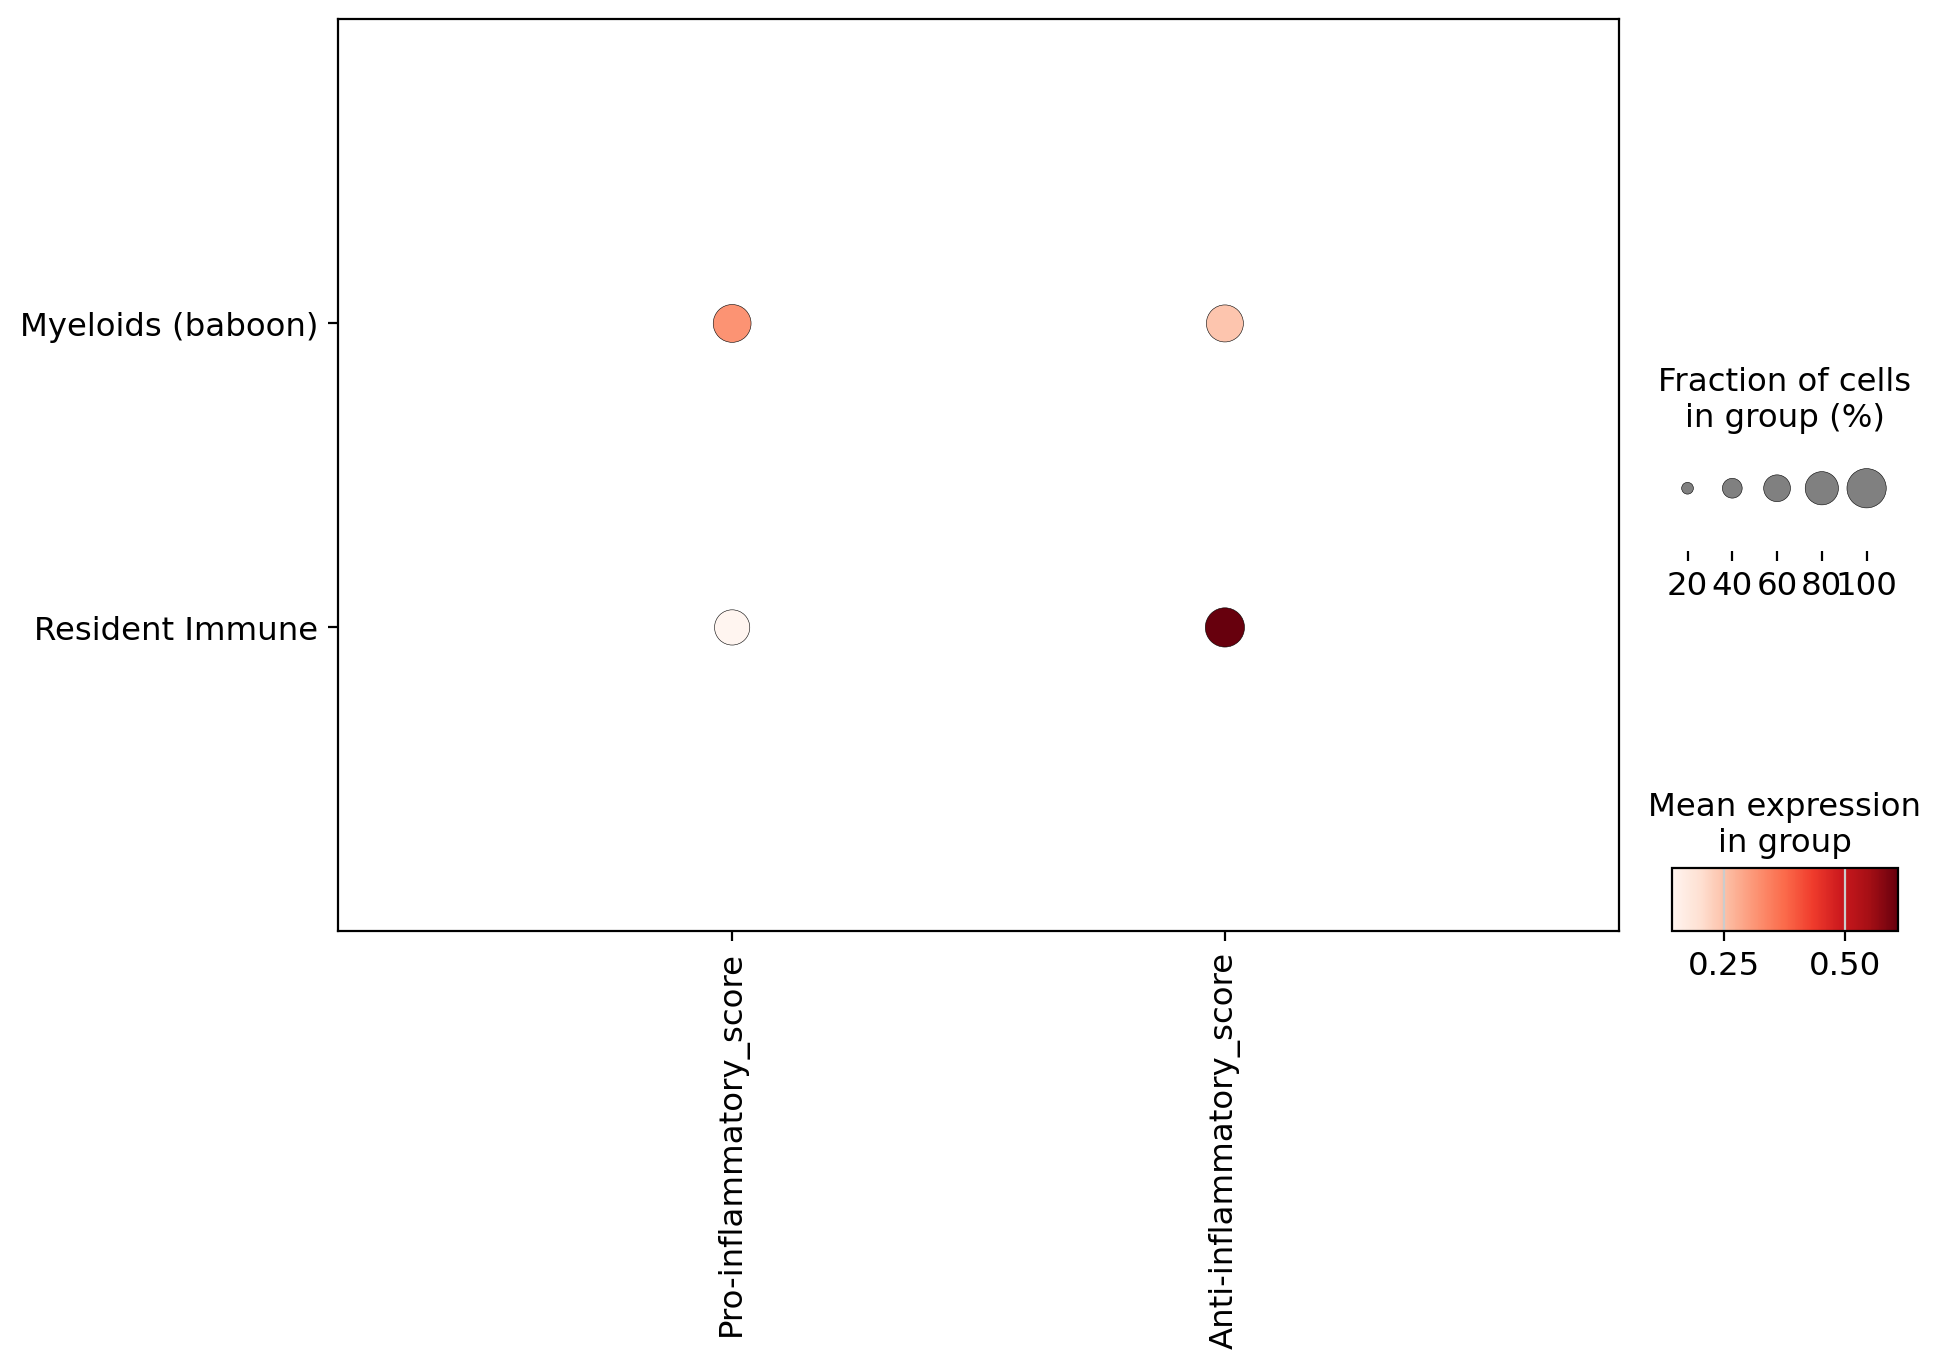

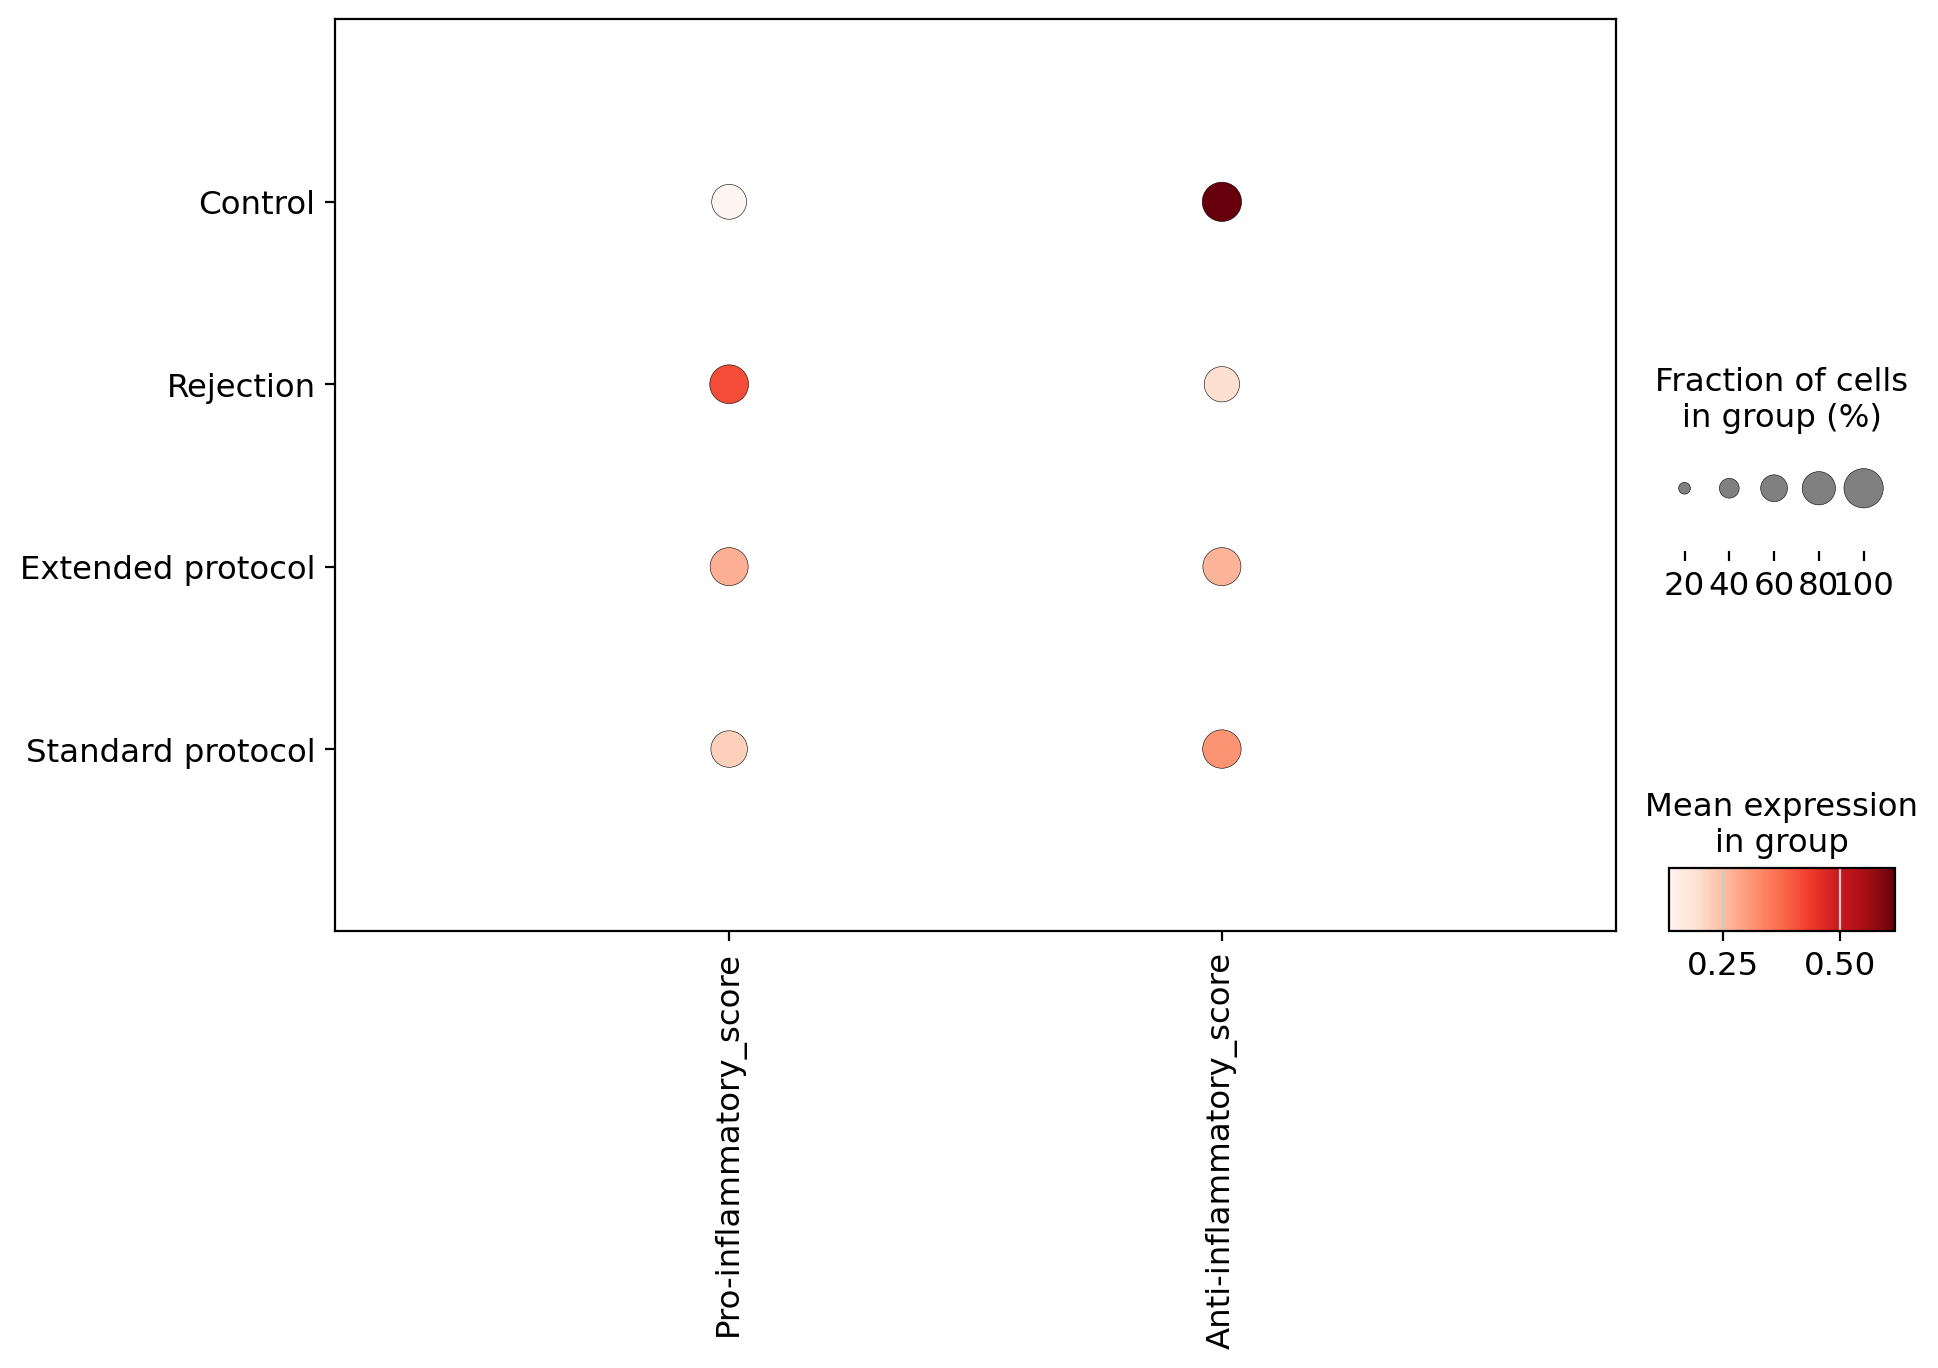

In [20]:
# Plot dot plot of gene set scores by cluster
sc.pl.dotplot(
    adata,
    var_names=[pathway_name + "_score" for pathway_name in pathways.keys()],
    groupby='cell_type',
    cmap='Reds',
    figsize=(10, 6)
)

sc.pl.dotplot(
    adata,
    var_names=[pathway_name + "_score" for pathway_name in pathways.keys()],
    groupby='Condition_subsets',
    cmap='Reds',
    figsize=(10, 6)
)


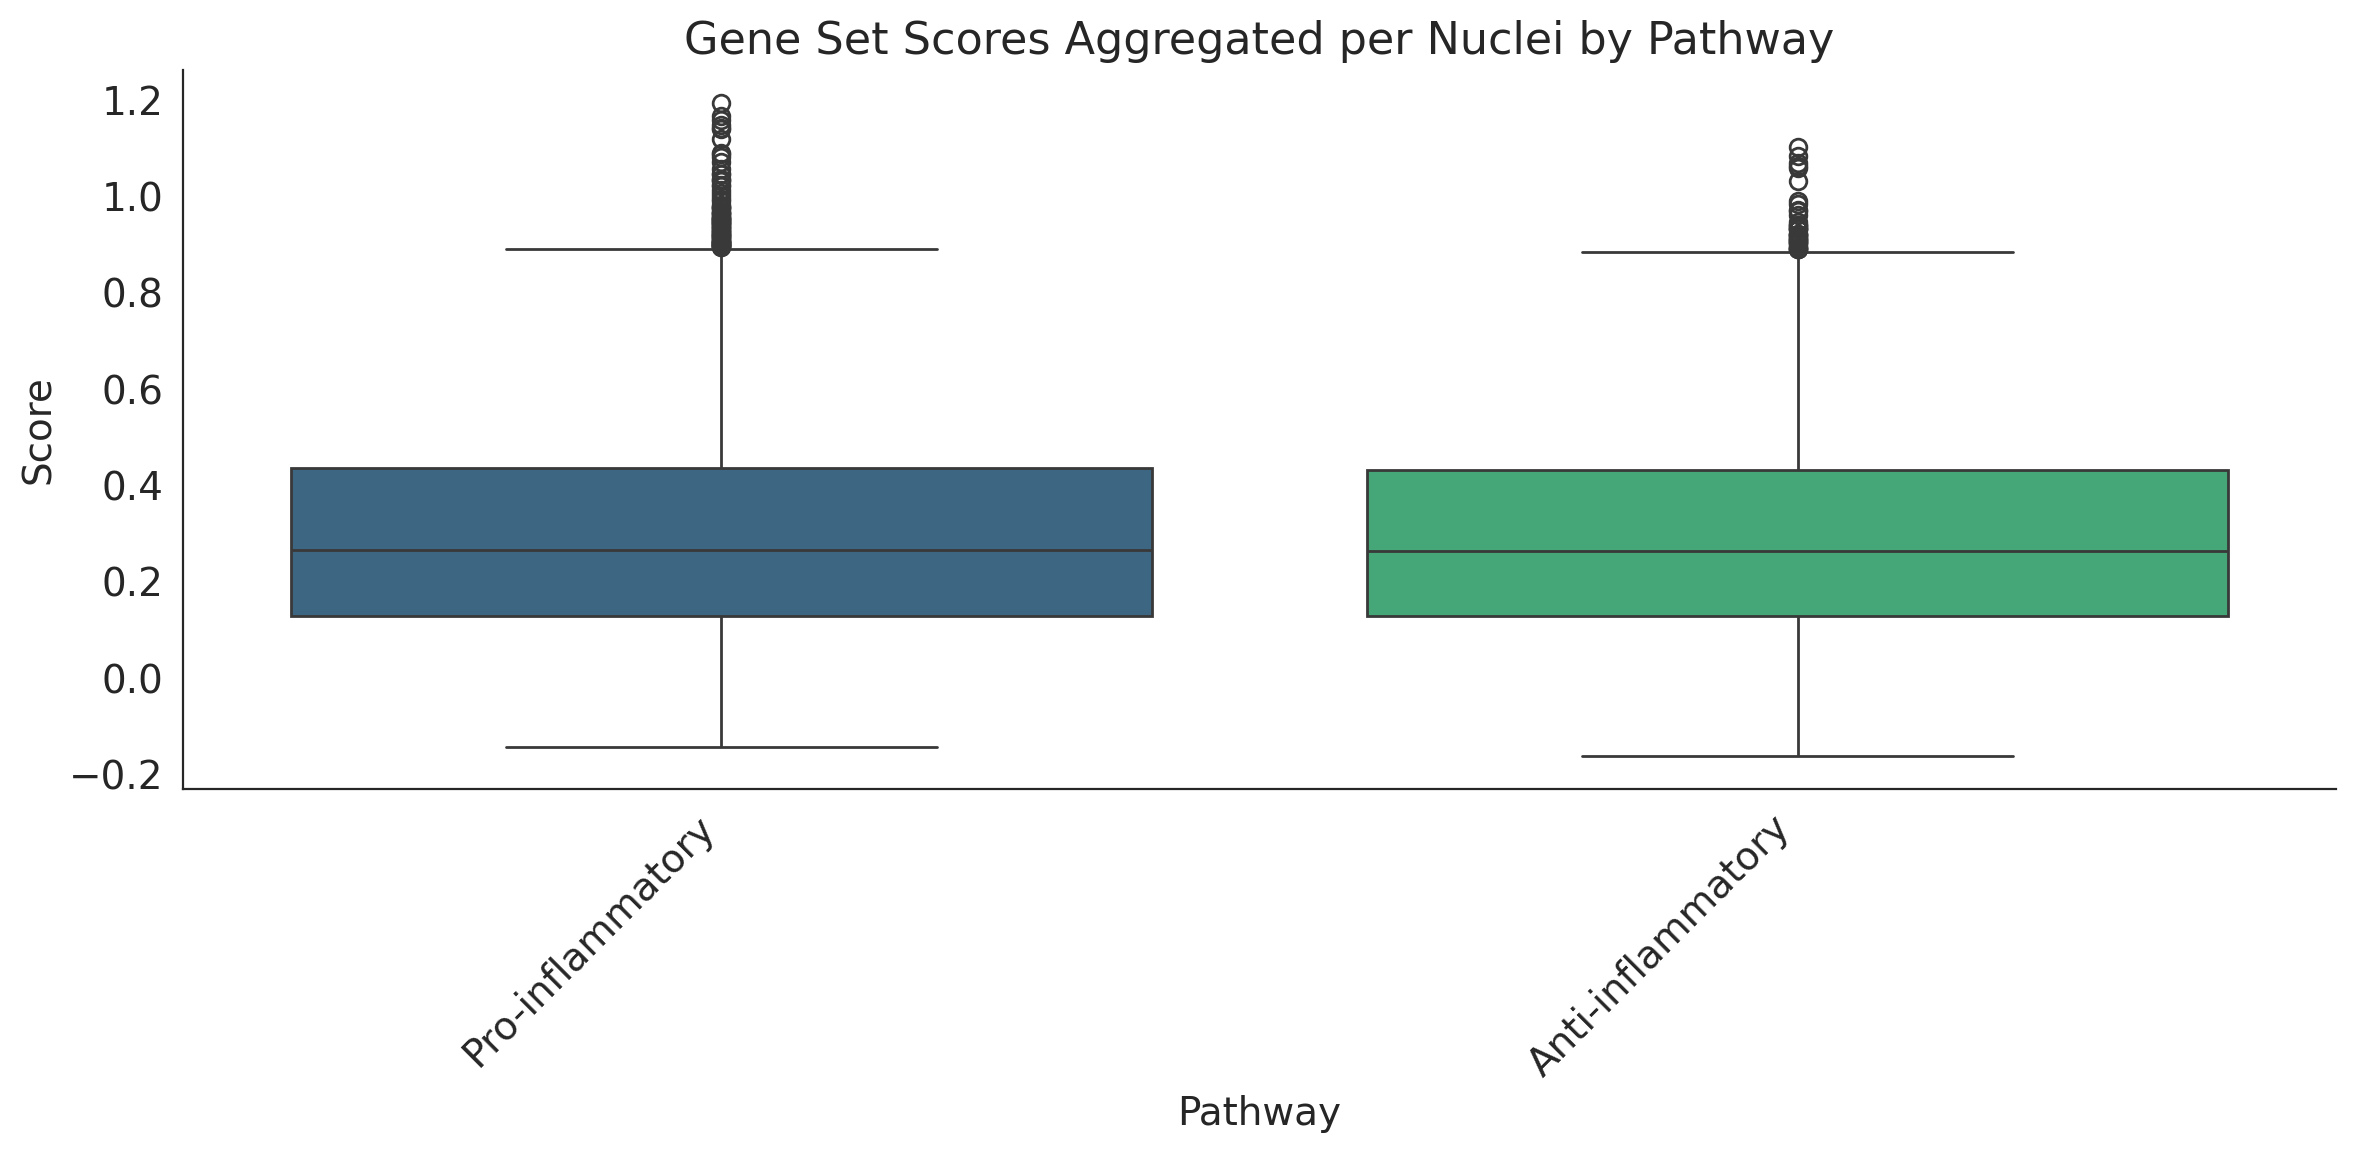

In [21]:
# Create a DataFrame to store the gene set scores
scores_df = pd.DataFrame()

# Extract gene set scores from adata.obs and add to the DataFrame
for pathway_name in pathways.keys():
    score_column = pathway_name + "_score"
    if score_column in adata.obs:
        scores_df[pathway_name] = adata.obs[score_column]
    else:
        print(f"Skipping {pathway_name}: No scores found in adata.obs.")

# Melt the DataFrame for seaborn
scores_df_melted = scores_df.melt(var_name='Pathway', value_name='Score')

# Set style first (before creating the plot)
sns.set_style("white")  # No grid, white background

# Then create your plot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=scores_df_melted,
    x='Pathway',
    y='Score',
    palette='viridis'
)

# Customize as before
plt.title('Gene Set Scores Aggregated per Nuclei by Pathway', fontsize=16)
plt.xlabel('Pathway', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Final cleanup (not strictly needed with "white" style)
ax.grid(False)
sns.despine()

plt.tight_layout()
plt.show()

In [18]:
## It shows usean gene set scores across all samples for each pathway
## Create a DataFrame to store the gene set scores and Sample_ID
#scores_df = pd.DataFrame()
#
## Extract gene set scores and Sample_ID
#for pathway_name in pathways.keys():
#    score_column = pathway_name + "_score"
#    if score_column in adata.obs:
#        # Add the scores and Sample_ID to the DataFrame
#        scores_df[pathway_name] = adata.obs[score_column]
#    else:
#        print(f"Skipping {pathway_name}: No scores found in adata.obs.")
#
## Add the Sample_ID information to the DataFrame
#scores_df['Sample_ID'] = adata.obs['Sample_ID']
#
## Group by Sample_ID and calculate the mean score for each pathway
#sample_scores_df = scores_df.groupby('Sample_ID').mean()
#
## Melt the DataFrame for seaborn
#sample_scores_melted = sample_scores_df.melt(var_name='Pathway', value_name='Score')
#
## Create a box plot
#plt.figure(figsize=(12, 6))
#sns.boxplot(
#    data=sample_scores_melted,
#    x='Pathway',
#    y='Score',
#    palette='magma'
#)
#
## Customize the plot
#plt.title('Gene Set Scores Aggregated per Sample_ID by Pathway (Mean)', fontsize=16)
#plt.xlabel('Pathway', fontsize=14)
#plt.ylabel('Score', fontsize=14)
#plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
#plt.tight_layout()
#
## Show the plot
#plt.show()

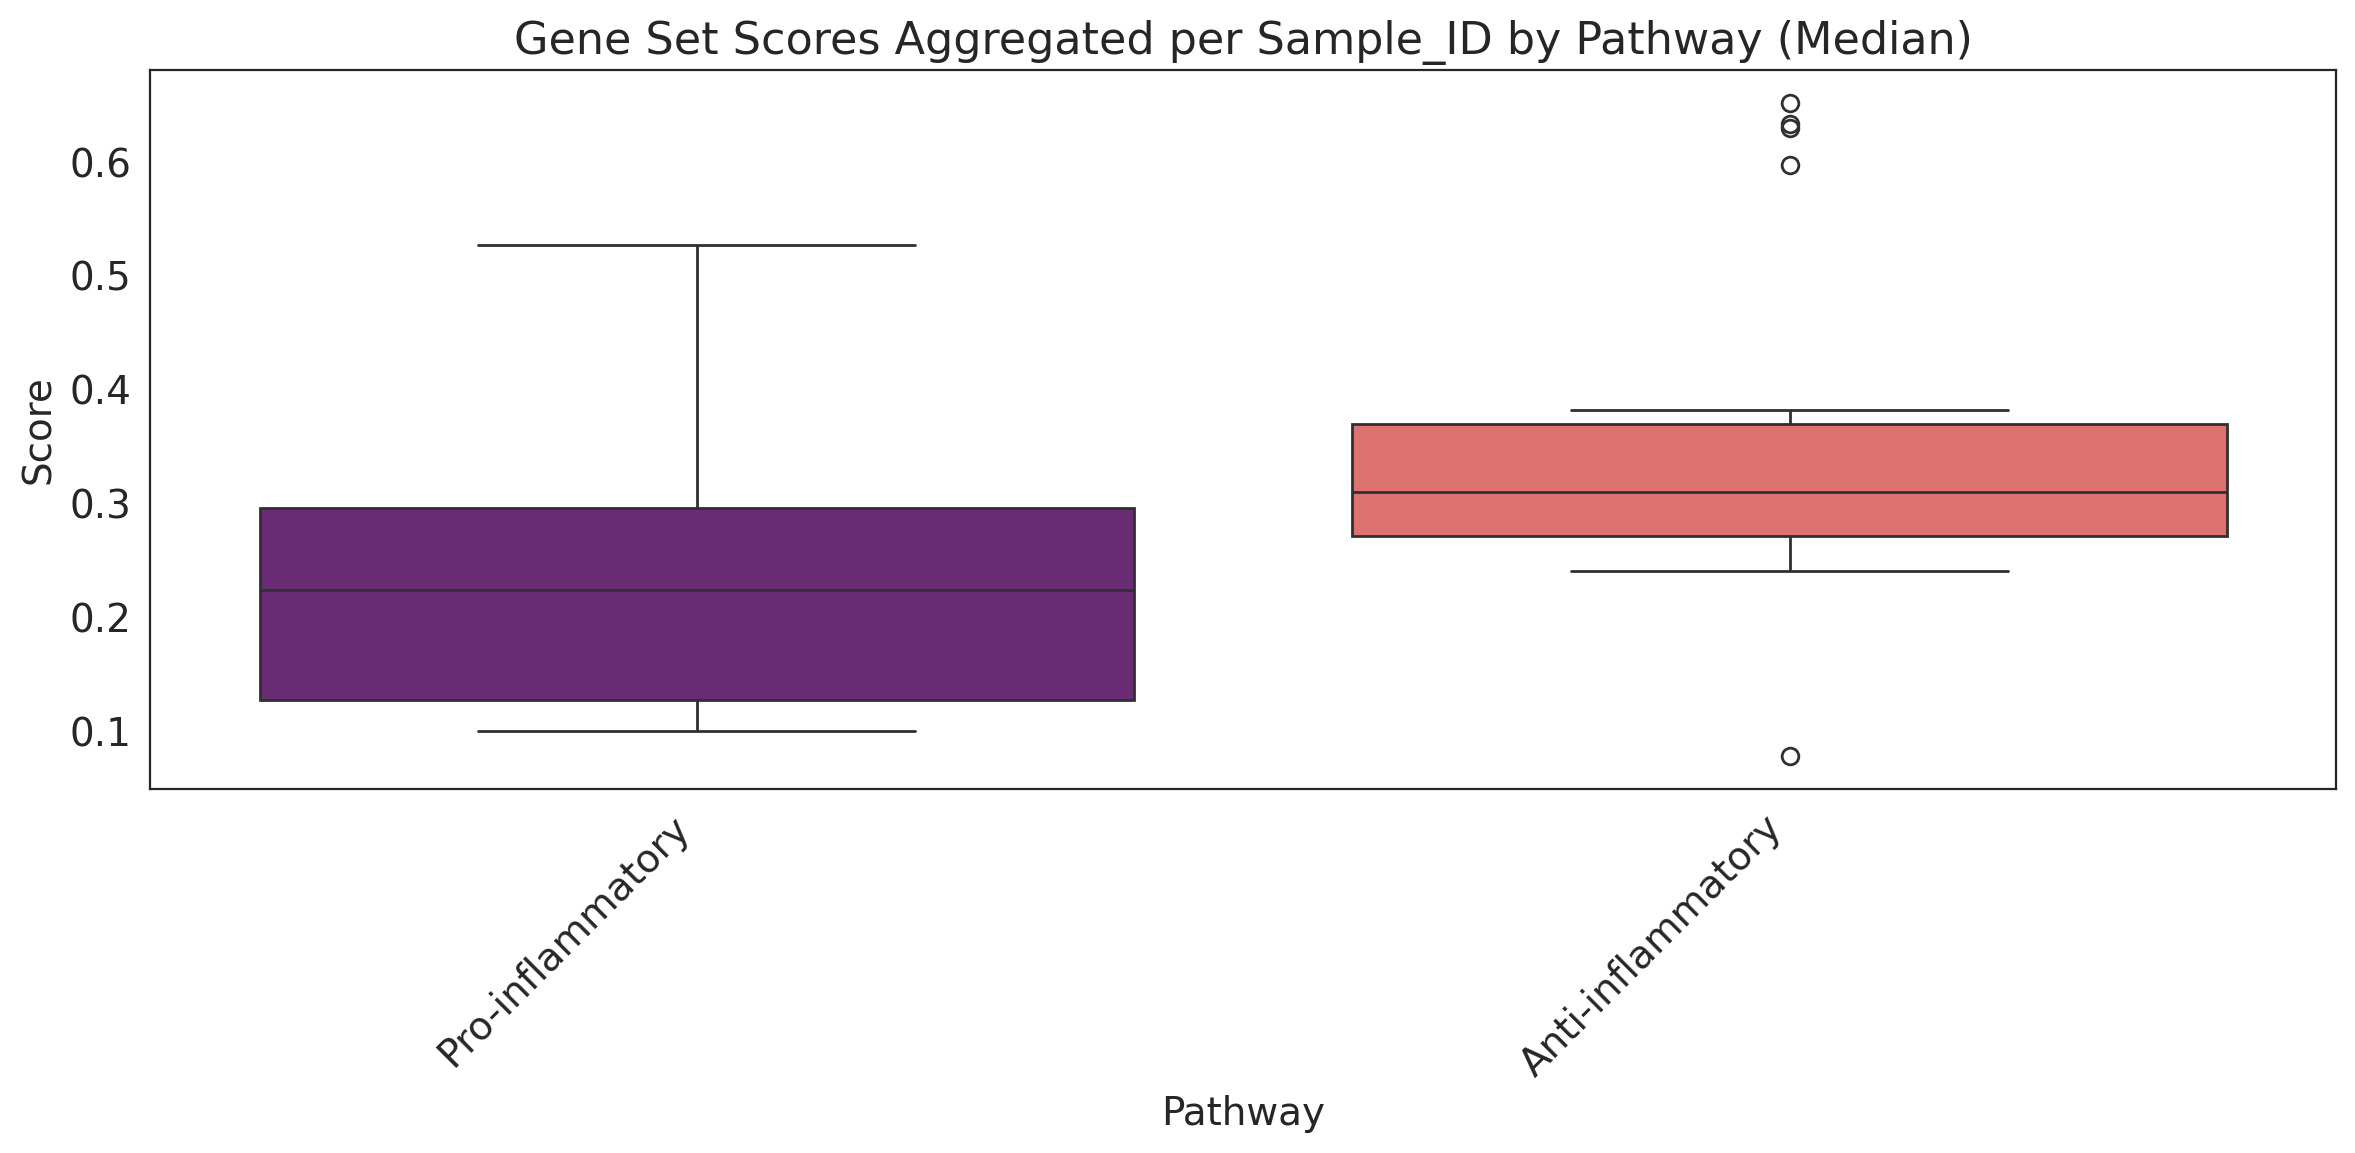

In [23]:
# It shows usean gene set scores across all samples for each pathway
# Create a DataFrame to store the gene set scores and Sample_ID
scores_df = pd.DataFrame()

# Extract gene set scores and Sample_ID
for pathway_name in pathways.keys():
    score_column = pathway_name + "_score"
    if score_column in adata.obs:
        # Add the scores and Sample_ID to the DataFrame
        scores_df[pathway_name] = adata.obs[score_column]
    else:
        print(f"Skipping {pathway_name}: No scores found in adata.obs.")

# Add the Sample_ID information to the DataFrame
scores_df['Sample_ID'] = adata.obs['Sample_ID']

# Group by Sample_ID and calculate the mean score for each pathway
sample_scores_df = scores_df.groupby('Sample_ID').median()

# Melt the DataFrame for seaborn
sample_scores_melted = sample_scores_df.melt(var_name='Pathway', value_name='Score')

# Create a box plot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=sample_scores_melted,
    x='Pathway',
    y='Score',
    palette='magma'
)

# Customize the plot
plt.title('Gene Set Scores Aggregated per Sample_ID by Pathway (Median)', fontsize=16)
plt.xlabel('Pathway', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()

# Show the plot
plt.show()

   Condition_subsets           Pathway     Score
0            Control  Pro-inflammatory  0.152660
1            Control  Pro-inflammatory  0.106309
2            Control  Pro-inflammatory  0.110286
3            Control  Pro-inflammatory  0.119270
4  Standard protocol  Pro-inflammatory  0.236424


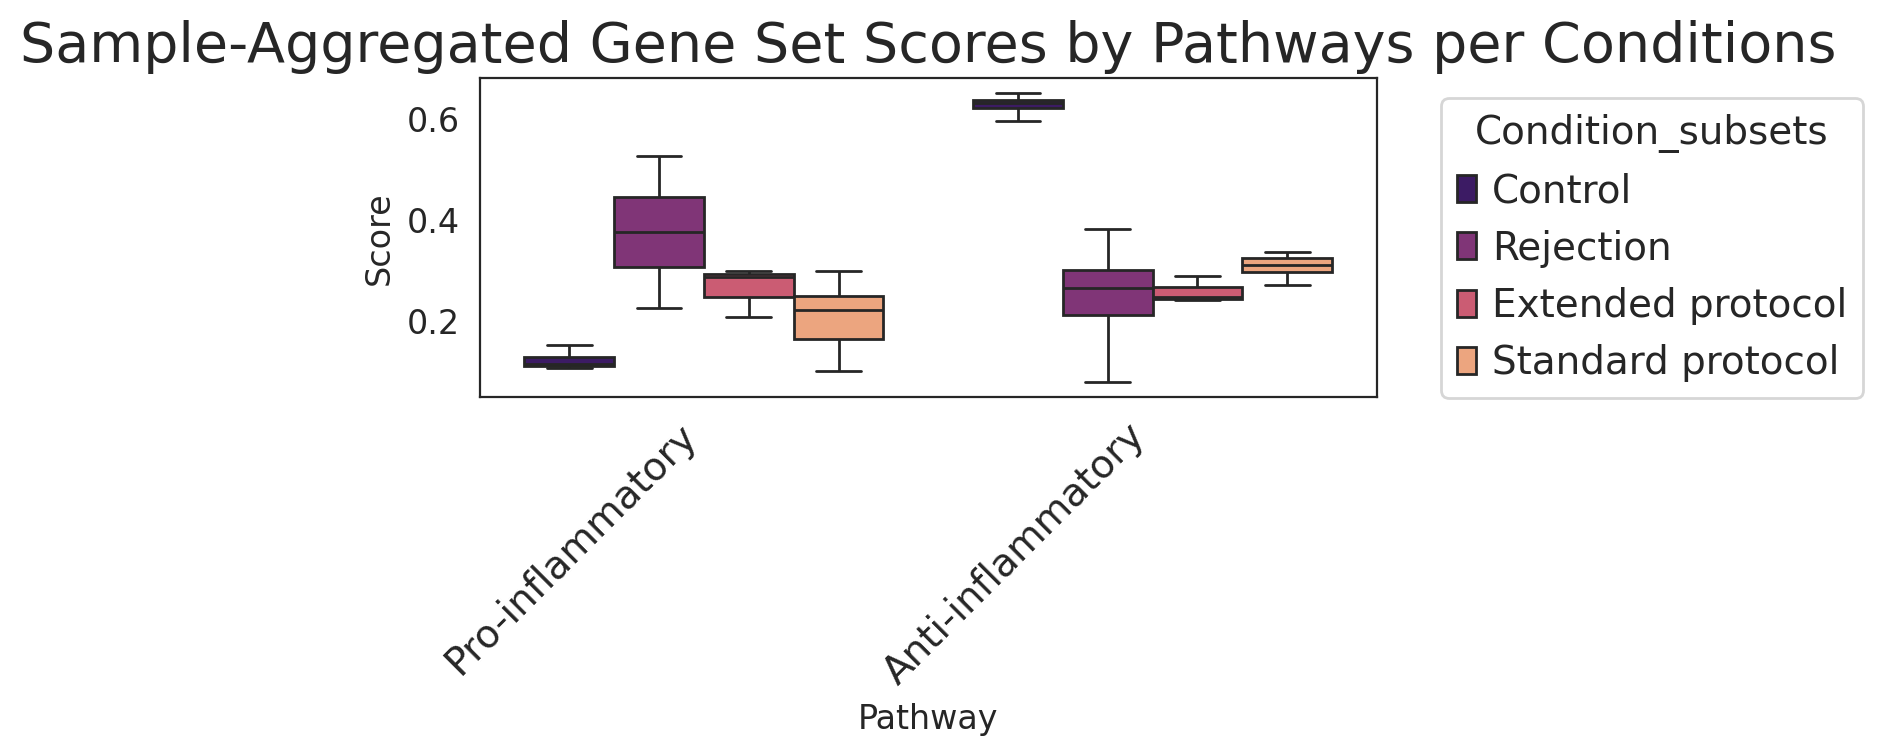

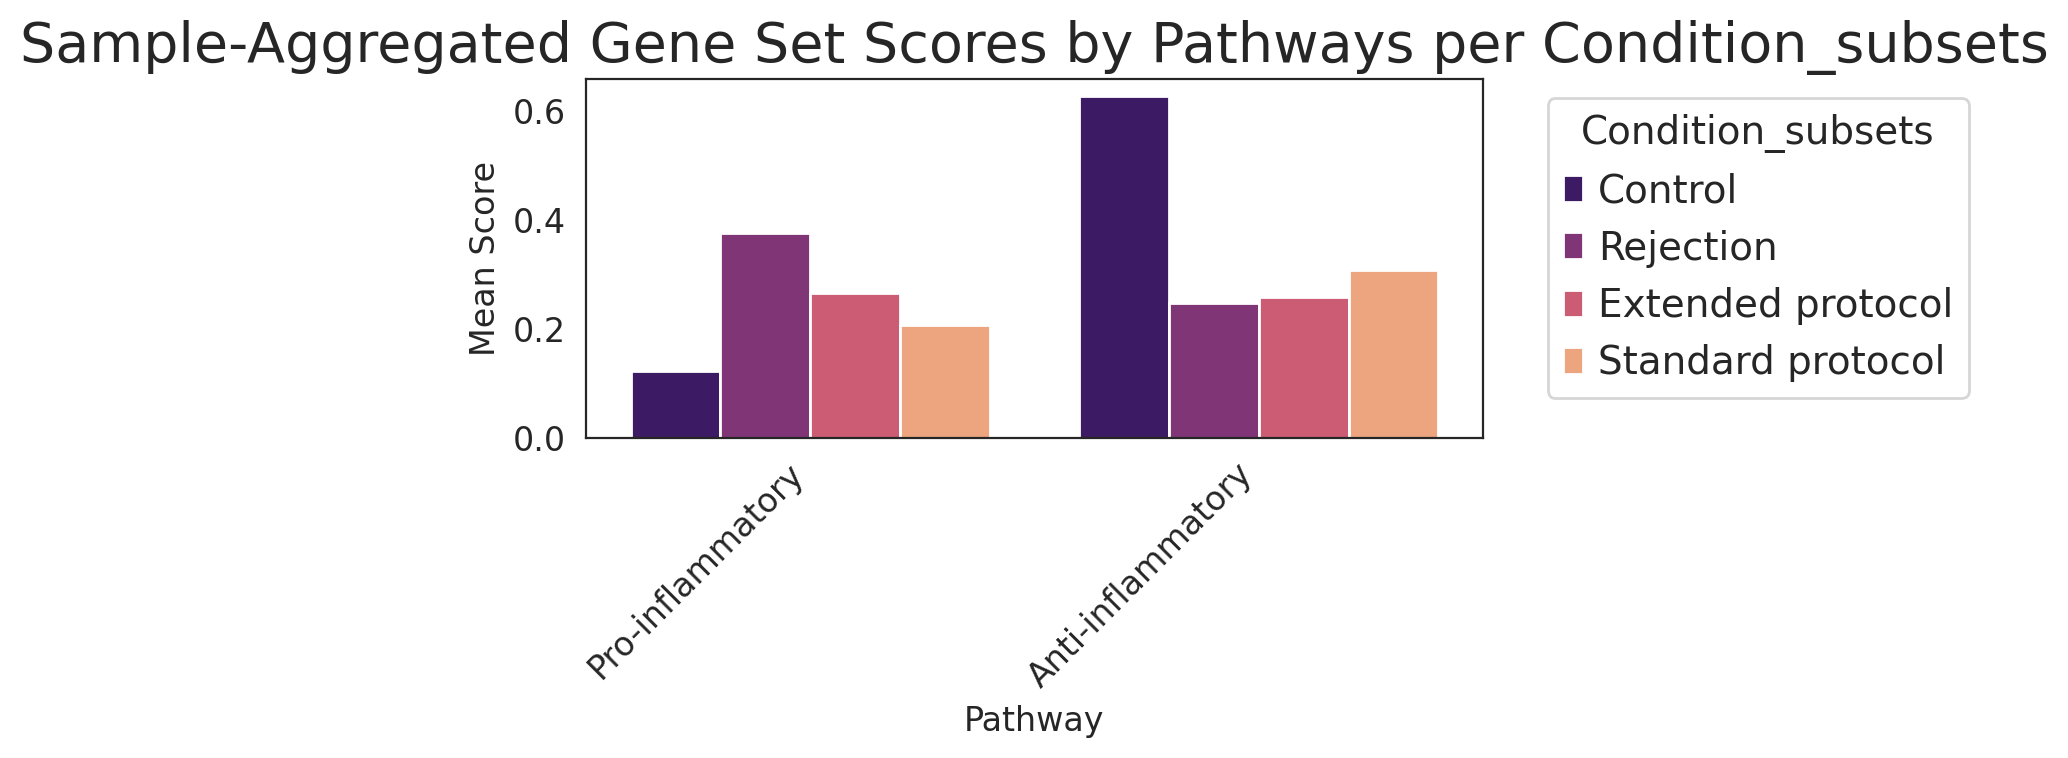

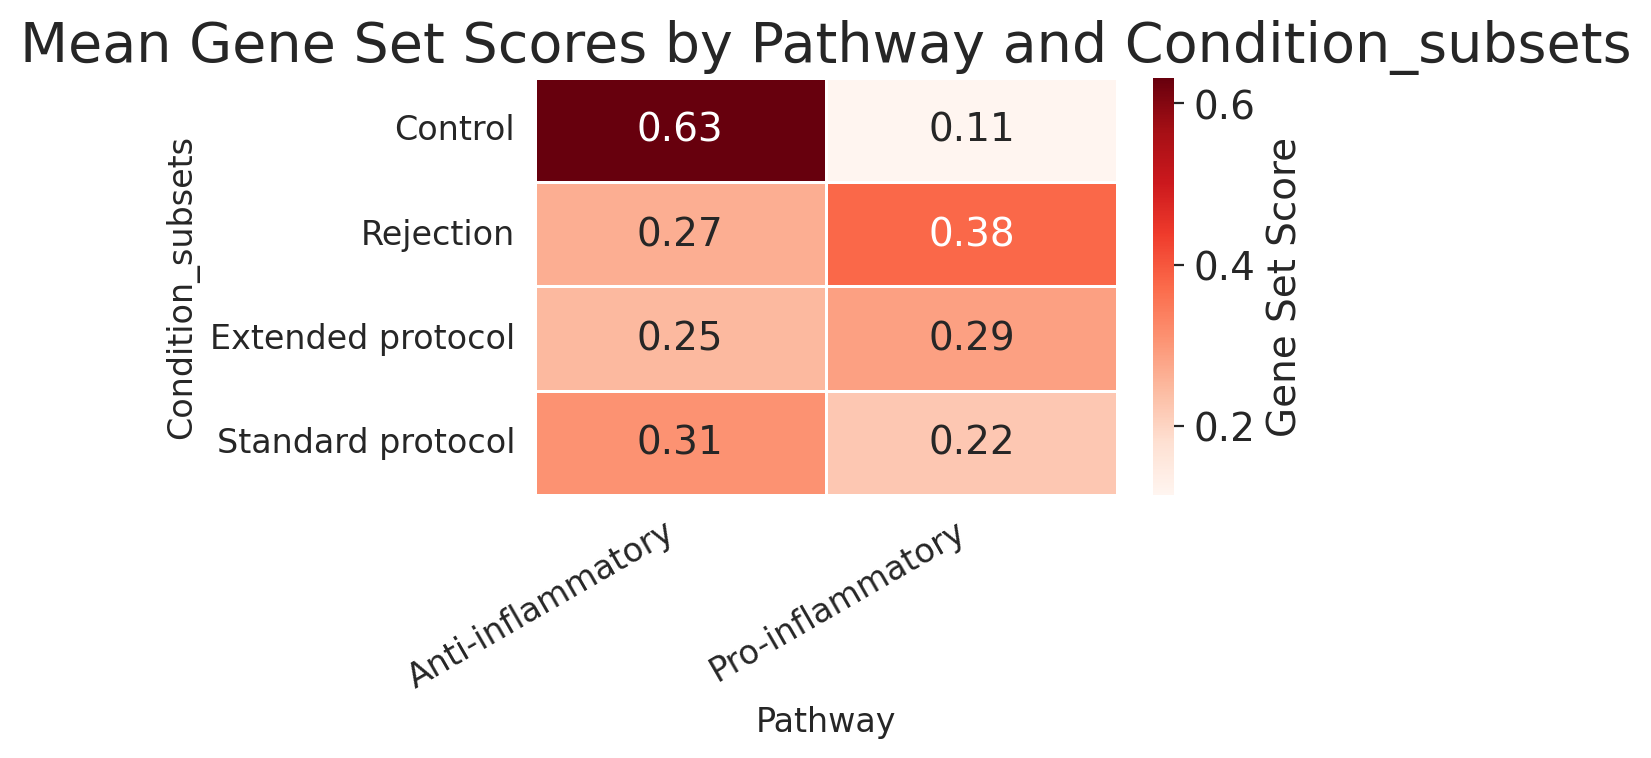

In [24]:
# Add new_endpoints information to the sample_scores_df DataFrame
sample_scores_df['Condition_subsets'] = adata.obs.groupby('Sample_ID')['Condition_subsets'].first()
# Melt the DataFrame for seaborn
sample_scores_melted = sample_scores_df.melt(
    id_vars='Condition_subsets',  # Include new_endpoints information
    var_name='Pathway', 
    value_name='Score'
)

# Verify the melted DataFrame
print(sample_scores_melted.head())

# Create a box plot
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=sample_scores_melted,
    x='Pathway',
    y='Score',
    hue='Condition_subsets',  # Color by new_endpoints
    palette='magma'
)

# Customize the plot
plt.title('Sample-Aggregated Gene Set Scores by Pathways per Conditions', fontsize=20)
plt.xlabel('Pathway', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=14)  # Rotate x-axis labels for better readability
plt.yticks(fontsize=12)  # Increase y-axis tick font size
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title='Condition_subsets')  # Move legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()


# Create a bar plot
plt.figure(figsize=(8, 4))
sns.barplot(
    data=sample_scores_melted,
    x='Pathway',
    y='Score',
    hue='Condition_subsets',  # Color by new_endpoints
    palette='magma',
    estimator='mean',  # Use mean for aggregation
    ci=None  # Disable confidence intervals
)

# Customize the plot
plt.title('Sample-Aggregated Gene Set Scores by Pathways per Condition_subsets', fontsize=20)
plt.xlabel('Pathway', fontsize=12)
plt.ylabel('Mean Score', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)  # Rotate x-axis labels for better readability
plt.yticks(fontsize=12)  # Increase y-axis tick font size
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title='Condition_subsets')  # Move legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()

# Pivot the melted DataFrame to create a matrix for the heatmap
heatmap_data = sample_scores_melted.pivot_table(
    index='Condition_subsets',  # Rows: new_endpoints
    columns='Pathway',      # Columns: Pathways
    values='Score',         # Values: Gene set scores
    aggfunc='median'          # Aggregate by mean (or median if preferred)
)

# Create the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    heatmap_data,
    cmap='Reds',  # Color map
    annot=True,      # Annotate cells with values
    fmt=".2f",       # Format annotations to 2 decimal places
    linewidths=0.5,  # Add lines between cells
    cbar_kws={'label': 'Gene Set Score'}  # Add a label to the color bar
)

# Customize the plot
plt.title('Mean Gene Set Scores by Pathway and Condition_subsets', fontsize=20)
plt.xlabel('Pathway', fontsize=12)
plt.ylabel('Condition_subsets', fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=12)  # Rotate x-axis labels for better readability
plt.yticks(fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()

# Pro + Anti inflamm polarization - Boxplot 

   Condition_subsets           Pathway     Score
0            Control  Pro-inflammatory  0.152660
1            Control  Pro-inflammatory  0.106309
2            Control  Pro-inflammatory  0.110286
3            Control  Pro-inflammatory  0.119270
4  Standard protocol  Pro-inflammatory  0.236424


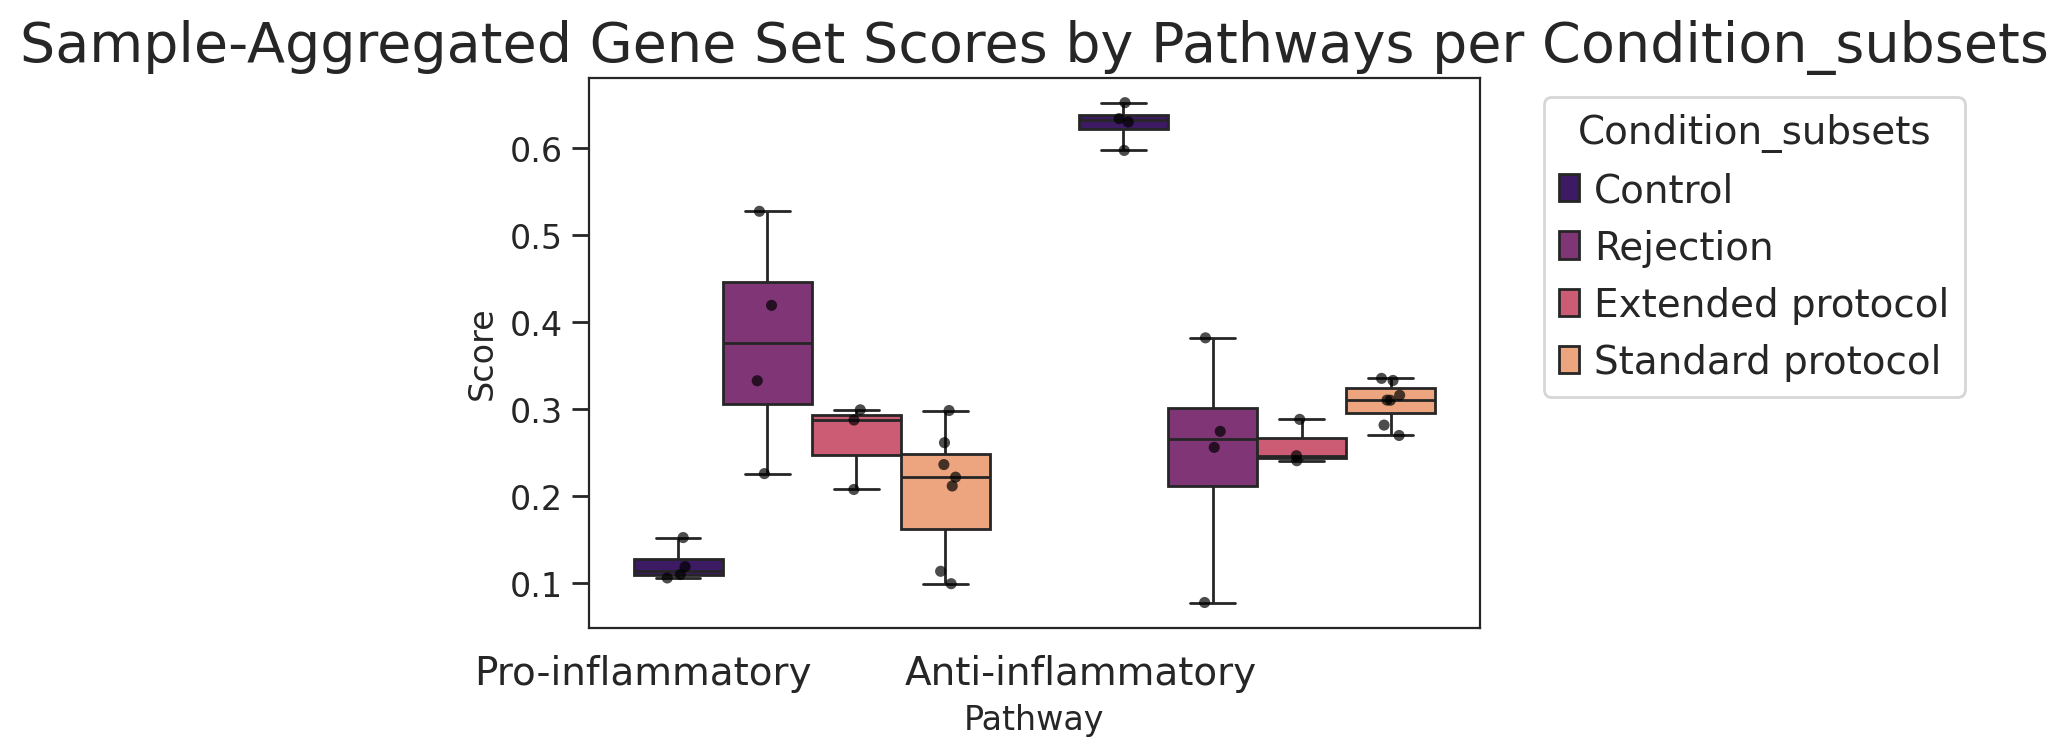

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure editable text in PDF exports
plt.rcParams['pdf.fonttype'] = 42

# Add Conditions column from adata.obs
sample_scores_df['Condition_subsets'] = adata.obs.groupby('Sample_ID')['Condition_subsets'].first()

# Melt the DataFrame for seaborn
sample_scores_melted = sample_scores_df.melt(
    id_vars='Condition_subsets',  # Include new_endpoints information
    var_name='Pathway',
    value_name='Score'
)

# Verify the melted DataFrame
print(sample_scores_melted.head())

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 4))

# Draw the box plot
sns.boxplot(
    data=sample_scores_melted,
    x='Pathway',
    y='Score',
    hue='Condition_subsets',     # Color by new_endpoints
    palette='magma',
    ax=ax
)

# Overlay individual samples as black points
sns.stripplot(
    data=sample_scores_melted,
    x='Pathway',
    y='Score',
    hue='Condition_subsets',
    dodge=True,
    palette=['black'],    # All points in black
    size=4,
    alpha=0.7,
    linewidth=0,
    legend=False,
    ax=ax
)

# Y-axis ticks on left, styled
ax.yaxis.set_ticks_position('left')
ax.tick_params(axis='y', which='major', length=6, width=1.0, labelsize=12)

# Restore and rotate x-axis labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    ha='right',
    fontsize=14
)
ax.tick_params(axis='x', length=6)

# Titles and labels
ax.set_title(
    'Sample-Aggregated Gene Set Scores by Pathways per Condition_subsets',
    fontsize=20
)
ax.set_xlabel('Pathway', fontsize=12)
ax.set_ylabel('Score', fontsize=12)

# Legend outside the plot
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=14,
    title='Condition_subsets'
)

plt.tight_layout()
plt.show()


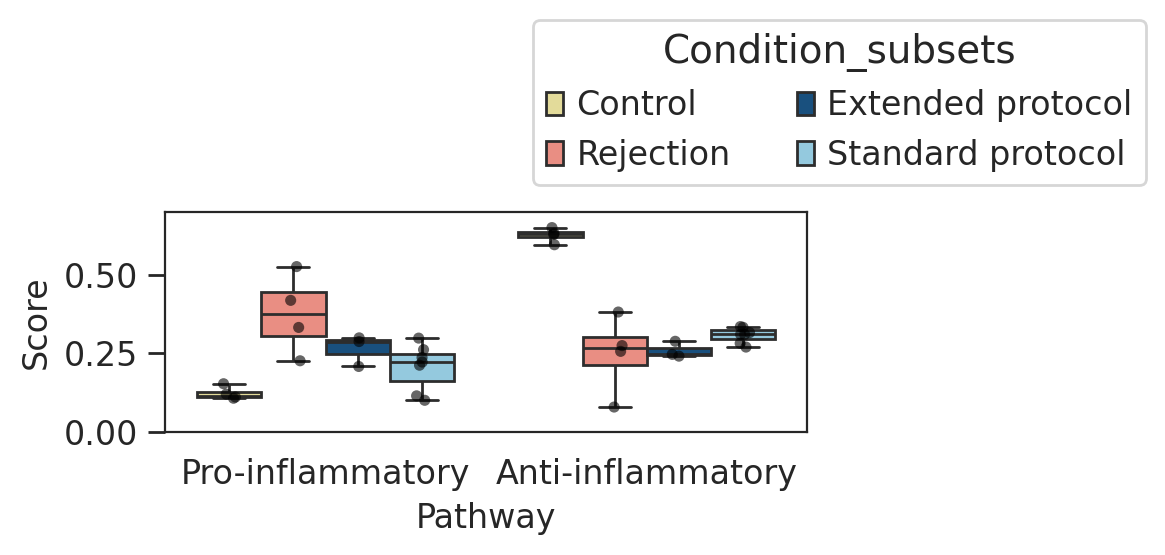

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Ensure editable text in PDF exports
plt.rcParams['pdf.fonttype'] = 42

# User-configurable settings
color_palette = {'Rejection': 'salmon', 'Standard protocol': 'skyblue', 'Extended protocol': '#08528f', 'Control': '#EFE48E'}  # change group colors here
y_axis_limit = 0.7  # set the maximum y-axis limit here

# Add Conditions column
sample_scores_df['Condition_subsets'] = adata.obs.groupby('Sample_ID')['Condition_subsets'].first()

# Melt for seaborn
sample_scores_melted = sample_scores_df.melt(
    id_vars='Condition_subsets',
    var_name='Pathway',
    value_name='Score'
)

# Compute Wilcoxon (Mann-Whitney U) p-values for each pathway
pathways = sample_scores_melted['Pathway'].unique()
pvals = []
for pw in pathways:
    grp = sample_scores_melted[sample_scores_melted['Pathway'] == pw]
    x = grp[grp['Condition_subsets'] == 'Standard protocol']['Score'].dropna()
    y = grp[grp['Condition_subsets'] == 'Rejection']['Score'].dropna()
    if len(x) > 0 and len(y) > 0:
        _, p = mannwhitneyu(x, y, alternative='two-sided')
    else:
        p = float('nan')
    pvals.append(p)

# Adjust for multiple testing (FDR Benjamini–Hochberg)
_, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')
sig_levels = []
for p in pvals_adj:
    if p < 0.001:
        sig_levels.append('***')
    elif p < 0.01:
        sig_levels.append('**')
    elif p < 0.05:
        sig_levels.append('*')
    else:
        sig_levels.append('ns')

# Create figure
fig, ax = plt.subplots(figsize=(6, 3))

# Boxplot with custom palette
sns.boxplot(
    data=sample_scores_melted,
    x='Pathway',
    y='Score',
    hue='Condition_subsets',
    palette=color_palette,
    width=0.8,
    ax=ax
)

# Stripplot overlay (keep black points)
sns.stripplot(
    data=sample_scores_melted,
    x='Pathway',
    y='Score',
    hue='Condition_subsets',
    dodge=True,
    palette=['black'],
    size=4,
    alpha=0.6,
    linewidth=0,
    legend=False,
    ax=ax
)

# Annotate significance at center of each group
for i, pw in enumerate(pathways):
    if sig_levels[i] and sig_levels[i] != 'ns':
        ax.text(
            i,
            y_axis_limit * 1.02,
            sig_levels[i],
            ha='center',
            va='bottom',
            fontsize=14,
            fontweight='bold'
        )

# Set y-axis limit
ax.set_ylim(0, y_axis_limit)

# Y-axis ticks styling
ax.yaxis.set_ticks_position('left')
ax.tick_params(axis='y', which='major', labelsize=12, length=6, width=1.0)

# Restore & rotate x-axis labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    ha='center',
    fontsize=12
)
ax.tick_params(axis='x', length=6)

# Titles and labels
ax.set_title('', fontsize=20)
ax.set_xlabel('Pathway', fontsize=12)
ax.set_ylabel('Score', fontsize=12)

# Legend in middle of plot
leg = ax.legend(
    bbox_to_anchor=(1.05, 1.05),
    loc='lower center',
    ncol=2,
    title='Condition_subsets',
    fontsize=12
)
leg._legend_box.align = "center"

plt.tight_layout()

# -- Save to user-defined path and filename --
#pdf_folder = '/data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/GSEA_Immune_Cells/GSEA_M1_M2_pol_RESULTS/'  # Optional
#pdf_name = 'GSEA_MPs_filtered_overall_change_increase_of_M1_and_decrease_of_M2.pdf'  # Change this to your desired filename
#output_path = pdf_folder + pdf_name  # Or just output_path = 'your_full_path.pdf'
#plt.savefig(output_path, format='pdf', bbox_inches='tight', pad_inches=0.1)

plt.show()


In [27]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def get_pathway_pvalues_with_logfc(sample_scores_melted):
    """
    Computes two-sided Mann–Whitney U p-values for each pathway comparing
    'Standard protocol' vs. 'Rejection', applies FDR correction, calculates log fold change,
    and returns a DataFrame with pathway, raw p, adjusted p, significance stars, and logFC.

    Parameters:
        sample_scores_melted (pd.DataFrame): Must have columns
            ['Pathway', 'Score', 'Condition_subsets'] where Condition_subsets ∈ {'Standard protocol', 'Rejection'}.

    Returns:
        pd.DataFrame with columns:
            Pathway, p_value, p_adjusted, significance, logFC
    """
    pathways = sample_scores_melted['Pathway'].unique()
    pvals = []
    logfc = []
    for pw in pathways:
        grp = sample_scores_melted[sample_scores_melted['Pathway'] == pw]
        x = grp[grp['Condition_subsets'] == 'Rejection']['Score'].dropna()
        y = grp[grp['Condition_subsets'] == 'Standard protocol']['Score'].dropna()
        if len(x) > 0 and len(y) > 0:
            _, p = mannwhitneyu(x, y, alternative='two-sided')
            # Calculate log fold change as log2(mean(Standard protocol) / mean(Rejection))
            mean_x = np.mean(x)
            mean_y = np.mean(y)
            # Add a small constant to avoid division by zero or log of zero
            mean_x = mean_x if mean_x > 0 else 1e-9
            mean_y = mean_y if mean_y > 0 else 1e-9
            logfc_val = np.log2(mean_x / mean_y)
        else:
            p = float('nan')
            logfc_val = float('nan')
        pvals.append(p)
        logfc.append(logfc_val)

    # FDR correction
    _, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')

    # Significance stars
    sig = []
    for p in pvals_adj:
        if pd.isna(p):
            sig.append('ns')
        elif p < 0.001:
            sig.append('***')
        elif p < 0.01:
            sig.append('**')
        elif p < 0.05:
            sig.append('*')
        else:
            sig.append('ns')

    return pd.DataFrame({
        'Pathway': pathways,
        'p_value': pvals,
        'p_adjusted': pvals_adj,
        'significance': sig,
        'logFC': logfc
    })

# Example usage:
pval_df = get_pathway_pvalues_with_logfc(sample_scores_melted)
print(pval_df.to_string(index=False))


          Pathway  p_value  p_adjusted significance     logFC
 Pro-inflammatory 0.042424    0.084848           ns  0.866904
Anti-inflammatory 0.315152    0.315152           ns -0.314765


In [28]:
adata

AnnData object with n_obs × n_vars = 10238 × 40653
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets', 'Pro-inflammatory_score', 'Anti-inflammatory_score'
    uns: 'Sample_ID_colors', 'log1p'
    obsm: 'X_pca', 'X_umap'

In [29]:
# Create a summary table with Sample_ID, Condition, M1-score, and M2-score

# If your sample_scores_df already has a 'Conditions' column (as added previously),
# you don’t need to pull it again from adata.obs.
# Just reset the index (if needed) and select the columns you want.

# 1. Ensure Sample_ID is a column
if sample_scores_df.index.name == 'Sample_ID':
    summary_df = sample_scores_df.reset_index().copy()
else:
    summary_df = sample_scores_df.copy()

# 2. Select the existing 'Conditions' column (no re-lookup needed) plus your scores
#    Replace 'M1' and 'M2' with the actual column names if they differ.
table_df = summary_df[['Sample_ID', 'Condition_subsets', 'Pro-inflammatory', 'Anti-inflammatory']].rename(
    columns={
        'Conditions': 'Condition_subsets',
        'M1 polarization': 'Pro-inflammatory',
        'M2 polarization': 'Anti-inflammatory'
    }
)

# 3. Display the table
from IPython.display import display
display(table_df)


,Sample_ID,Condition_subsets,Pro-inflammatory,Anti-inflammatory
0,B,Control,0.152660,0.629506
1,E,Control,0.106309,0.651672
2,F,Control,0.110286,0.633372
3,G,Control,0.119270,0.596873
4,PAV65,Standard protocol,0.236424,0.310407
5,PAV66,Standard protocol,0.221985,0.281720
6,PAV67,Standard protocol,0.113975,0.310218
7,PAV69,Standard protocol,0.099714,0.335308
8,PAV71,Extended protocol,0.299273,0.288276
9,PAV72,Extended protocol,0.207819,0.240823


In [30]:
# -- Save summary table to user-defined path and filename --
csv_folder = '/data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/GSEA_Immune_Cells/GSEA_M1_M2_pol_RESULTS/'  # Optional: change to your desired folder
csv_name = 'GSEA_MPs_filtered_M1_M2_scores.csv'  # Change this to your desired filename
output_csv = csv_folder + csv_name  # Or just output_csv = 'your_full_path.csv'
table_df.to_csv(output_csv, index=False)

# Other Methods to present data: Sorting by M1 and M2 in Legend 

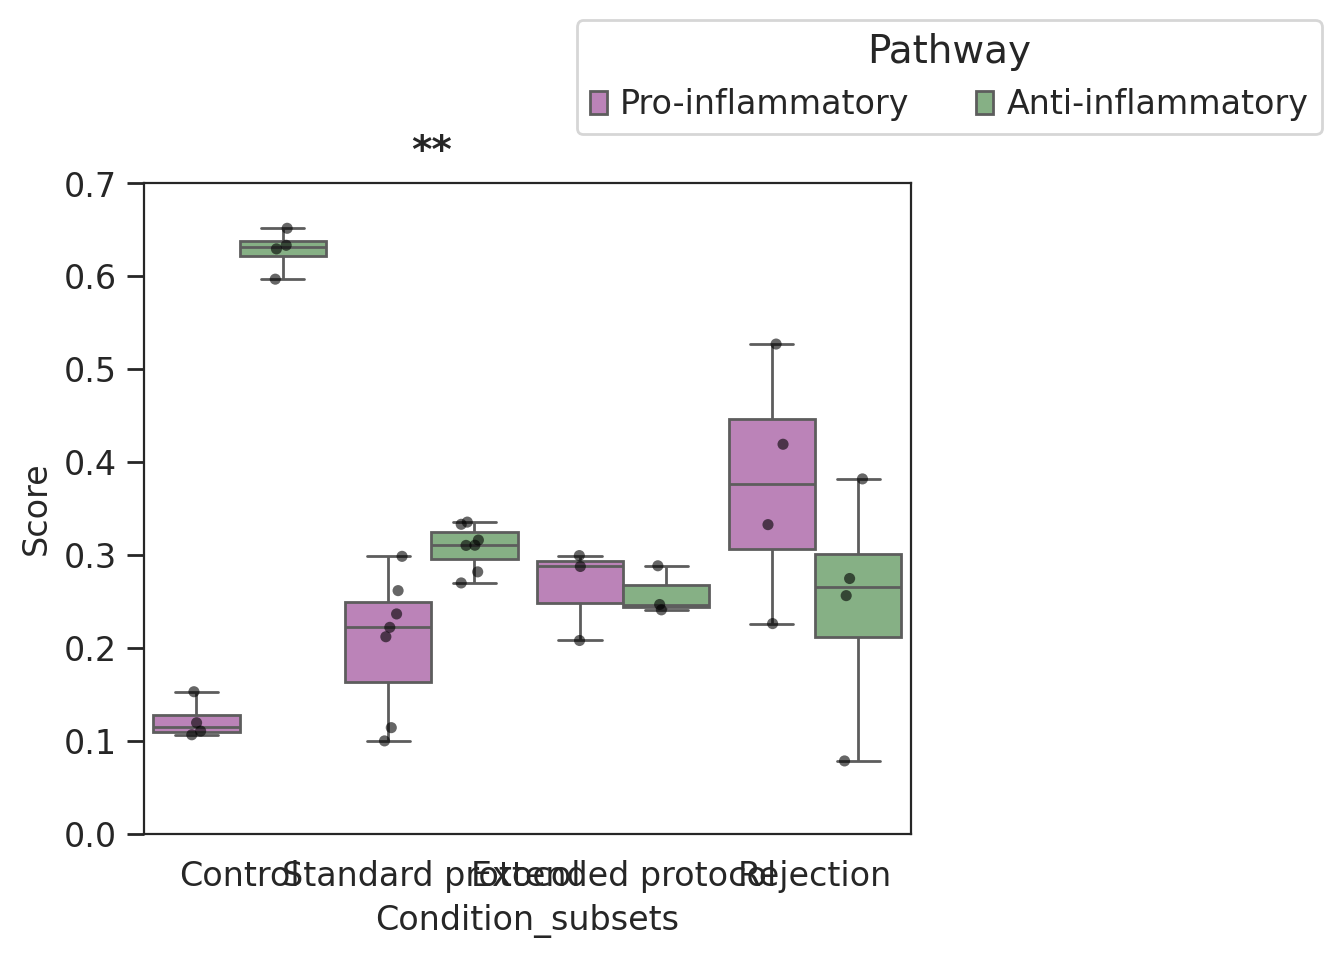

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Ensure editable text in PDF exports
plt.rcParams['pdf.fonttype'] = 42

# User-configurable settings for pathway colors
pathway_palette = {
    'Pro-inflammatory': '#C47AC0',   # muted brown
    'Anti-inflammatory': '#7FB77E',  # muted sage green
    # Add more pathways and colors as needed
}

y_axis_limit = 0.7  # set the maximum y-axis limit here

# Specify the desired order for Condition_subsets on the x-axis
condition_order = ['Control', 'Standard protocol', 'Extended protocol', 'Rejection']

# Melt for seaborn (already done)
# sample_scores_melted = sample_scores_df.melt(...)

# Compute Wilcoxon (Mann-Whitney U) p-values for each Condition_subsets (now on x-axis)
groups = sample_scores_melted['Condition_subsets'].unique()
pvals = []
for group in groups:
    grp = sample_scores_melted[sample_scores_melted['Condition_subsets'] == group]
    x = grp[grp['Pathway'] == sample_scores_melted['Pathway'].unique()[0]]['Score'].dropna()
    y = grp[grp['Pathway'] == sample_scores_melted['Pathway'].unique()[1]]['Score'].dropna()
    if len(x) > 0 and len(y) > 0:
        _, p = mannwhitneyu(x, y, alternative='two-sided')
    else:
        p = float('nan')
    pvals.append(p)

# Adjust for multiple testing (FDR Benjamini–Hochberg)
_, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')
sig_levels = []
for p in pvals_adj:
    if p < 0.001:
        sig_levels.append('***')
    elif p < 0.01:
        sig_levels.append('**')
    elif p < 0.05:
        sig_levels.append('*')
    else:
        sig_levels.append('ns')

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Boxplot with specified order
sns.boxplot(
    data=sample_scores_melted,
    x='Condition_subsets',
    y='Score',
    hue='Pathway',
    palette=pathway_palette,
    width=0.9,
    ax=ax,
    order=condition_order  # Specify the x-axis order here
)

# Stripplot overlay with the same order
sns.stripplot(
    data=sample_scores_melted,
    x='Condition_subsets',
    y='Score',
    hue='Pathway',
    dodge=True,
    palette=['black'],
    size=4,
    alpha=0.6,
    linewidth=0,
    legend=False,
    ax=ax,
    order=condition_order  # Specify the x-axis order here
)

# Annotate significance at center of each group
for i, group in enumerate(groups):
    if sig_levels[i] and sig_levels[i] != 'ns':
        ax.text(
            i,
            y_axis_limit * 1.02,
            sig_levels[i],
            ha='center',
            va='bottom',
            fontsize=14,
            fontweight='bold'
        )

# Set y-axis limit
ax.set_ylim(0, y_axis_limit)

# Y-axis ticks styling
ax.yaxis.set_ticks_position('left')
ax.tick_params(axis='y', which='major', labelsize=12, length=6, width=1.0)

# Restore & rotate x-axis labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    ha='center',
    fontsize=12
)
ax.tick_params(axis='x', length=6)

# Titles and labels
ax.set_title('', fontsize=20)
ax.set_xlabel('Condition_subsets', fontsize=12)
ax.set_ylabel('Score', fontsize=12)

# Legend for Pathway
leg = ax.legend(
    bbox_to_anchor=(1.05, 1.05),
    loc='lower center',
    ncol=2,
    title='Pathway',
    fontsize=12
)
leg._legend_box.align = "center"

plt.tight_layout()

# -- Save to user-defined path and filename --
# plt.savefig(output_path, format='pdf', bbox_inches='tight', pad_inches=0.1)

plt.show()


In [32]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def compute_stats_table(sample_scores_melted):
    groups = sample_scores_melted['Condition_subsets'].unique()
    pathways = sample_scores_melted['Pathway'].unique()
    results = []

    for group in groups:
        grp = sample_scores_melted[sample_scores_melted['Condition_subsets'] == group]
        x = grp[grp['Pathway'] == pathways[0]]['Score'].dropna()
        y = grp[grp['Pathway'] == pathways[1]]['Score'].dropna()
        if len(x) > 0 and len(y) > 0:
            _, p = mannwhitneyu(x, y, alternative='two-sided')
            mean_x = x.mean()
            mean_y = y.mean()
            log2fc = np.log2(mean_x / mean_y) if mean_y != 0 else np.nan
        else:
            p = np.nan
            log2fc = np.nan
        results.append({
            'Condition_subsets': group,
            'Pro-inflammatory': pathways[0],
            'Anti-inflammatory': pathways[1],
            'p-value': p,
            'Log2 Fold Change': log2fc
        })

    # Adjust p-values for multiple testing
    pvals = [r['p-value'] for r in results]
    _, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')
    for i, padj in enumerate(pvals_adj):
        results[i]['Adjusted p-value'] = padj

    return pd.DataFrame(results)

# Usage:
table_df = compute_stats_table(sample_scores_melted)
display(table_df)


,Condition_subsets,Pro-inflammatory,Anti-inflammatory,p-value,Log2 Fold Change,Adjusted p-value
0,Control,Pro-inflammatory,Anti-inflammatory,0.028571,-2.362002,0.057143
1,Standard protocol,Pro-inflammatory,Anti-inflammatory,0.002331,-0.578609,0.009324
2,Extended protocol,Pro-inflammatory,Anti-inflammatory,1.000000,0.034826,1.000000
3,Rejection,Pro-inflammatory,Anti-inflammatory,0.342857,0.603060,0.457143


# ALL Myeloids sus + papio: Control vs Rejection 

In [33]:
boxprops = dict(edgecolor='black', linewidth=1.0)
medianprops = dict(color='black', linewidth=1.5)
whiskerprops = dict(color='black', linewidth=1.0)
capprops = dict(color='black', linewidth=1.0)


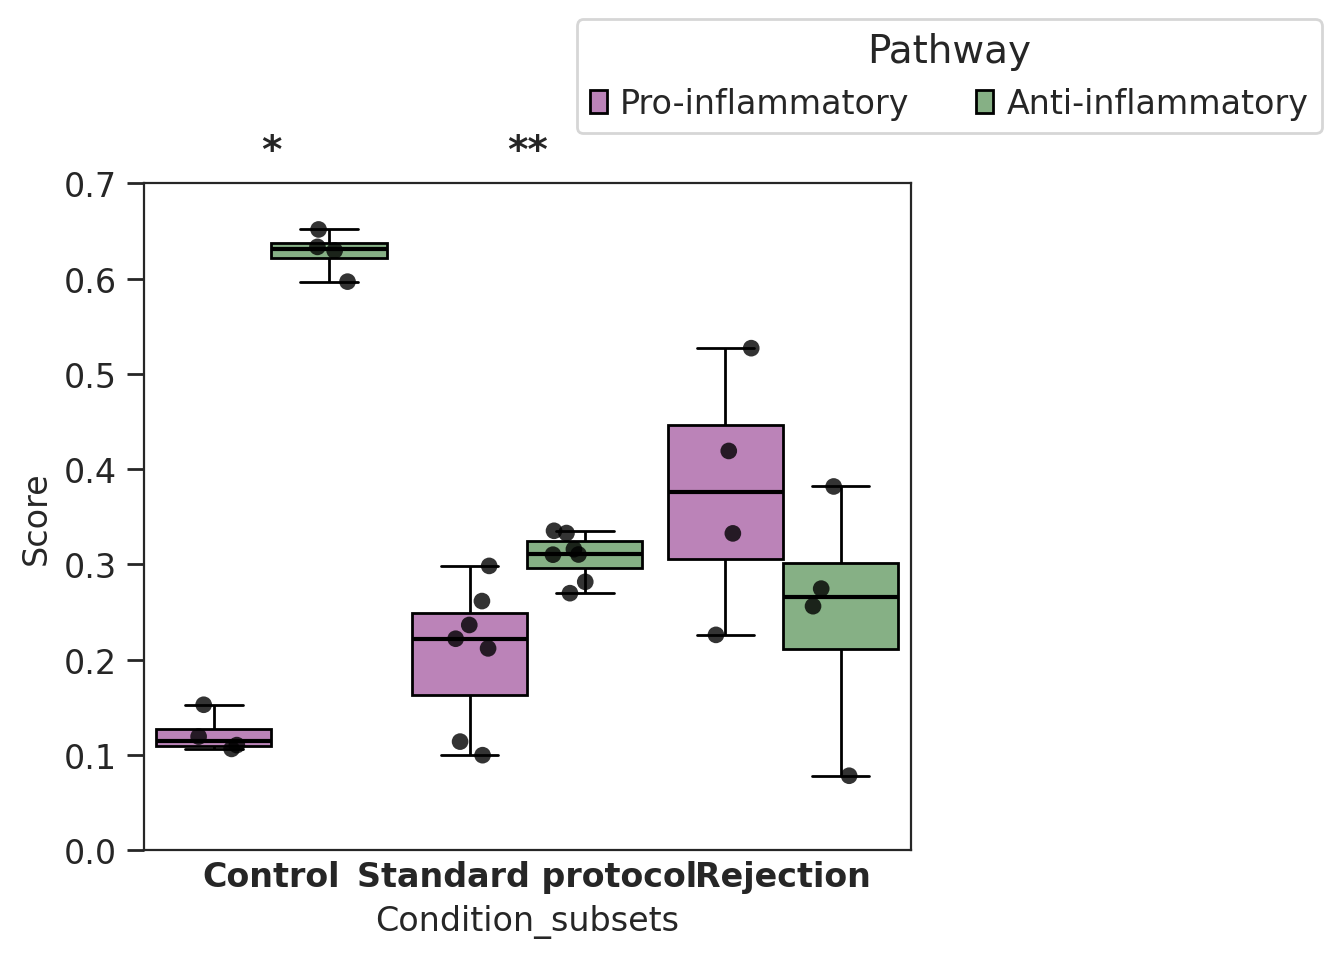

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Ensure editable text in PDF exports
plt.rcParams['pdf.fonttype'] = 42

# User-configurable settings for pathway colors
pathway_palette = {
    'Pro-inflammatory': '#C47AC0',   # muted brown
    'Anti-inflammatory': '#7FB77E',  # muted sage green
    # Add more pathways and colors as needed
}

y_axis_limit = 0.7  # set the maximum y-axis limit here

# All possible conditions
all_condition_order = ['Control', 'Standard protocol', 'Extended protocol', 'Rejection']

# Subset for current analysis (e.g., exclude 'Extended protocol' and 'Rejection')
analysis_condition_order = [cond for cond in all_condition_order if cond not in ['Extended protocol',]]

# Melt for seaborn (already done)
# sample_scores_melted = sample_scores_df.melt(...)

# Filter data for current analysis
filtered_sample_scores = sample_scores_melted[
    sample_scores_melted['Condition_subsets'].isin(analysis_condition_order)
]

# Compute Wilcoxon (Mann-Whitney U) p-values for each Condition_subsets (now on x-axis)
groups = analysis_condition_order  # Ensures consistent order
pvals = []
for group in groups:
    grp = filtered_sample_scores[filtered_sample_scores['Condition_subsets'] == group]
    x = grp[grp['Pathway'] == filtered_sample_scores['Pathway'].unique()[0]]['Score'].dropna()
    y = grp[grp['Pathway'] == filtered_sample_scores['Pathway'].unique()[1]]['Score'].dropna()
    if len(x) > 0 and len(y) > 0:
        _, p = mannwhitneyu(x, y, alternative='two-sided')
    else:
        p = float('nan')
    pvals.append(p)

# Adjust for multiple testing (FDR Benjamini–Hochberg)
_, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')
sig_levels = []
for p in pvals_adj:
    if p < 0.001:
        sig_levels.append('***')
    elif p < 0.01:
        sig_levels.append('**')
    elif p < 0.05:
        sig_levels.append('*')
    else:
        sig_levels.append('ns')

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Boxplot with specified order
sns.boxplot(
    data=filtered_sample_scores,
    x='Condition_subsets',
    y='Score',
    hue='Pathway',
    palette=pathway_palette,
    width=0.9,
    ax=ax,
    order=analysis_condition_order,
    boxprops=boxprops,
    medianprops=medianprops,
    whiskerprops=whiskerprops,
    capprops=capprops
)

# Stripplot overlay with the same order
sns.stripplot(
    data=filtered_sample_scores,
    x='Condition_subsets',
    y='Score',
    hue='Pathway',
    dodge=True,
    palette=['black'],
    size=6,
    alpha=0.8,
    jitter=0.2,
    linewidth=0,
    legend=False,
    ax=ax,
    order=analysis_condition_order
)

# Annotate significance at center of each group
for i, group in enumerate(groups):
    if sig_levels[i] and sig_levels[i] != 'ns':
        ax.text(
            i,
            y_axis_limit * 1.02,
            sig_levels[i],
            ha='center',
            va='bottom',
            fontsize=14,
            fontweight='bold'
        )

# Set y-axis limit
ax.set_ylim(0, y_axis_limit)

# Y-axis ticks styling
ax.yaxis.set_ticks_position('left')
ax.tick_params(axis='y', which='major', labelsize=12, length=6, width=1.0)

# Restore & rotate x-axis labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    ha='center',
    fontsize=12,
    fontweight='bold'
)
ax.tick_params(axis='x', length=0)

# Titles and labels
ax.set_title('', fontsize=20)
ax.set_xlabel('Condition_subsets', fontsize=12)
ax.set_ylabel('Score', fontsize=12)

# Legend for Pathway
leg = ax.legend(
    bbox_to_anchor=(1.05, 1.05),
    loc='lower center',
    ncol=2,
    title='Pathway',
    fontsize=12
)
leg._legend_box.align = "center"

plt.tight_layout()

# -- Save to user-defined path and filename --
#pdf_folder = '/data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/GSEA - Different Pathways/Macrophages_Ant_Pro_Inflammatory/Results_ALL_MP_Control_vs_Standard_vs_Rejection/'  # Optional
#pdf_name = 'Anti_Pro_Inflammatory_GSEA_All_Macrophages_Including_Control.pdf'  # Change this to your desired filename
#output_path = pdf_folder + pdf_name  # Or just output_path = 'your_full_path.pdf'
#plt.savefig(output_path, format='pdf', bbox_inches='tight', pad_inches=0.1, dpi=300)

plt.show()


# Cell_type level 

,cell_states,Pathway 1,Pathway 2,p-value,Log2 Fold Change,Sample_IDs Pathway 1,Scores Pathway 1,Sample_IDs Pathway 2,Scores Pathway 2,Adjusted p-value
0,MP_GBE1_papio,Pro-inflammatory,Anti-inflammatory,0.901515,0.079560,"[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]","[0.4974186317580087, 0.25105256395680564, 0.07392719939095634, 0.12907018870966774, 0.2174859867986742, 0.36212200568062924, 0.34061944360538404]","[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]","[0.42903049766335355, 0.18201651769317, 0.2135790963881587, 0.2697525650573013, 0.19860612331027389, 0.22167883365045915, 0.2566090867799515]",1.000000
1,MP_ISG_papio,Pro-inflammatory,Anti-inflammatory,0.011072,0.815382,"[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]","[0.538105755179269, 0.5708763174840382, 0.19343564608437674, 0.39316105683644614, 0.4330655658771465, 0.45719170138733184, 0.5354432218642462]","[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]","[0.23300233405380355, 0.1872953996336817, 0.25499196937777924, 0.1767854889028405, 0.2586825931128305, 0.35269125702701504, 0.3102429421868113]",0.038753
2,MP_LYVE1hi_1.0_sus,Pro-inflammatory,Anti-inflammatory,0.028571,-2.686002,"[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]","[0.13751188941228956, 0.010090470450265066, 0.010995011465890075, 0.2165481665475028]","[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]","[0.5447282774081008, 0.6077935613806921, 0.5483875169852053, 0.7132554409059898]",0.066667
3,MP_LYVE1hi_2.0_sus,Pro-inflammatory,Anti-inflammatory,1.000000,-2.506812,"[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]",[0.12331800842285157],"[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]",[0.7008938389563039],1.000000
4,MP_LYVE1hi_papio,Pro-inflammatory,Anti-inflammatory,0.000583,-1.012781,"[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]","[0.21531069812024356, 0.240024613484111, 0.11755755552953603, 0.11152096119218943, 0.24819402392582546, 0.2799788751104195, 0.30450144324406586]","[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]","[0.43243051964876, 0.3760983065822256, 0.4405227975354201, 0.4789411515286745, 0.4336841567999242, 0.46065978239948074, 0.43883950067528243]",0.008159
5,MP_LYVE1lo_papio,Pro-inflammatory,Anti-inflammatory,0.382867,-0.222624,"[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]","[0.2111518293296175, 0.2599286306089626, 0.15625910996494438, 0.1384959809614509, 0.21953027225566607, 0.29256641541453415, 0.3027706436531884]","[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]","[0.23720797857567855, 0.2631585692850162, 0.2778831842921424, 0.2900953743580998, 0.23959625228597228, 0.28153610266512813, 0.25497182480688896]",0.765734
6,MP_NFkB_papio,Pro-inflammatory,Anti-inflammatory,1.000000,-0.072067,"[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]","[0.3509435482025146, 0.37650559030260355, 0.18828946140834263, 0.15940403965541294, 0.3780795516967773, 0.29966959980555946, 0.45936900002615794]","[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]","[0.3337023099959648, 0.18457572590719867, 0.16797059566713085, 0.2780912322105345, 0.3627867733502066, 0.475683397396705, 0.5227664831853096]",1.000000
7,MP_NFkB_sus,Pro-inflammatory,Anti-inflammatory,1.000000,NaN,"[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]",[-0.016087151118687207],"[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]",[0.382458925355081],1.000000
8,MP_TREM2_papio,Pro-inflammatory,Anti-inflammatory,0.002331,-0.655038,"[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]","[0.2705211726506551, 0.22944484165156867, 0.10023699488705151, 0.08739128434090387, 0.1999625240177303, 0.20152691548211232, 0.260658981519086]","[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]","[0.33475702958046677, 0.2575977597953152, 0.3238053498218431, 0.33574754873972334, 0.28121529788149985, 0.2912698673861065, 0.3009898248626193]",0.016317
9,MP_TREM2_sus,Pro-inflammatory,Anti-inflammatory,1.000000,-1.699755,"[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, PAV82]",[0.19851237487792966],"[PAV65, PAV66, PAV67, PAV69, PAV75, PAV80, P

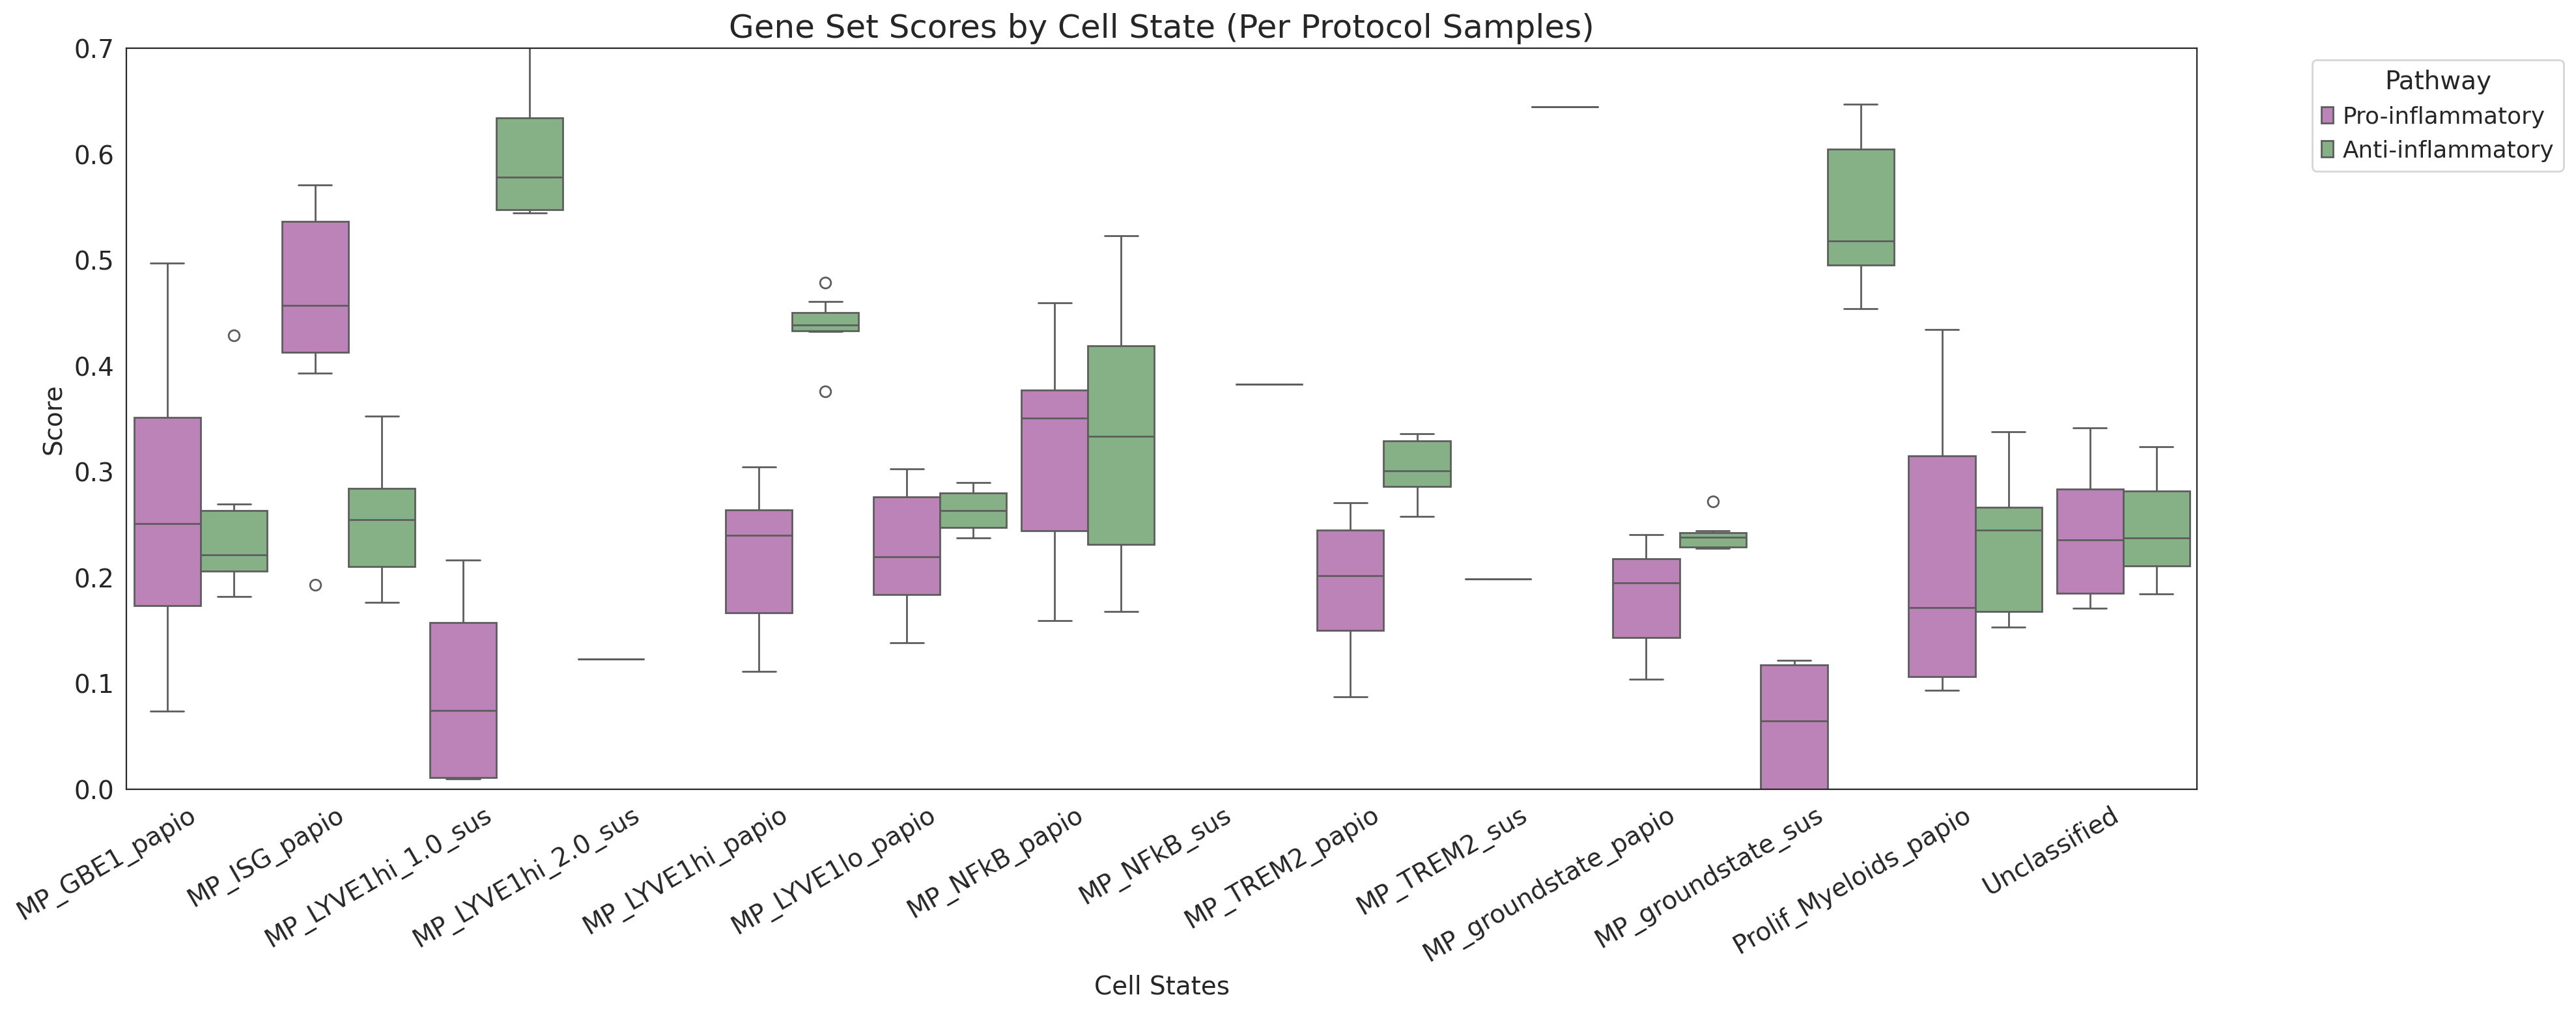

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For statistical testing
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ===== ADD THIS CRITICAL LINE =====
plt.rcParams['pdf.fonttype'] = 42  # Ensures editable text in PDFs
# ==================================

# User-configurable pathway color palette (muted green & magenta, colorblind-friendly)
pathway_palette = {
    'Pro-inflammatory': '#C47AC0',   # muted magenta
    'Anti-inflammatory': '#7FB77E',  # muted sage green
    # Add more pathways and colors as needed
}

y_axis_limit = 0.7  # set the maximum y-axis limit here

# Subset adata to only "Per protocol" samples (example: 'Rejection')
adata_pp = adata[adata.obs['Condition_subsets'] == 'Standard protocol'].copy()

# List of pathway names (e.g., ['Pro-inflammatory', 'Anti-inflammatory'])
# Make sure this matches the columns in your adata.obs
pathways = ['Pro-inflammatory', 'Anti-inflammatory']

# Create DataFrame with scores (only for Per protocol samples)
scores_df = pd.DataFrame()
for pathway_name in pathways:
    score_column = pathway_name + "_score"
    if score_column in adata_pp.obs:
        scores_df[pathway_name] = adata_pp.obs[score_column]

# Add metadata
scores_df['Sample_ID'] = adata_pp.obs['Sample_ID']
scores_df['cell_states'] = adata_pp.obs['cell_states']

# Group by cell state and sample, then take mean (if needed)
state_sample_scores = scores_df.groupby(['cell_states', 'Sample_ID']).mean().reset_index()

# Melt for plotting
state_sample_scores_melted = state_sample_scores.melt(
    id_vars=['cell_states', 'Sample_ID'],
    var_name='Pathway',
    value_name='Score'
)

# --- Statistical Table Function ---
def compute_stats_table_with_samples(state_sample_scores_melted):
    groups = state_sample_scores_melted['cell_states'].unique()
    pathways = state_sample_scores_melted['Pathway'].unique()
    results = []

    for group in groups:
        grp = state_sample_scores_melted[state_sample_scores_melted['cell_states'] == group]
        x = grp[grp['Pathway'] == pathways[0]]['Score'].dropna()
        y = grp[grp['Pathway'] == pathways[1]]['Score'].dropna()
        # Collect Sample_IDs and scores for each pathway
        sample_ids_x = grp[grp['Pathway'] == pathways[0]]['Sample_ID'].tolist()
        sample_ids_y = grp[grp['Pathway'] == pathways[1]]['Sample_ID'].tolist()
        scores_x = x.tolist()
        scores_y = y.tolist()

        if len(x) > 0 and len(y) > 0:
            _, p = mannwhitneyu(x, y, alternative='two-sided')
            mean_x = x.mean()
            mean_y = y.mean()
            log2fc = np.log2(mean_x / mean_y) if mean_y != 0 else np.nan
        else:
            p = np.nan
            log2fc = np.nan

        results.append({
            'cell_states': group,
            'Pathway 1': pathways[0],
            'Pathway 2': pathways[1],
            'p-value': p,
            'Log2 Fold Change': log2fc,
            'Sample_IDs Pathway 1': sample_ids_x,
            'Scores Pathway 1': scores_x,
            'Sample_IDs Pathway 2': sample_ids_y,
            'Scores Pathway 2': scores_y
        })

    # Adjust p-values for multiple testing
    pvals = [r['p-value'] for r in results]
    _, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')
    for i, padj in enumerate(pvals_adj):
        results[i]['Adjusted p-value'] = padj

    return pd.DataFrame(results)

# Generate and display the statistical table
table_df = compute_stats_table_with_samples(state_sample_scores_melted)
display(table_df)

# --- Plotting ---
plt.figure(figsize=(20, 8))
sns.boxplot(
    data=state_sample_scores_melted,
    x='cell_states',  # Cell states on x-axis
    y='Score',
    hue='Pathway',    # Pathways in legend
    palette=pathway_palette,  # Use your custom palette
    width=0.9
)

plt.title('Gene Set Scores by Cell State (Per Protocol Samples)', fontsize=18)
plt.xlabel('Cell States', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.ylim(0, y_axis_limit)
plt.xticks(rotation=30, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Pathway')
plt.tight_layout()

# -- Save to user-defined path and filename --
# pdf_folder = '/your/path/here/'
# pdf_name = 'GSEA_all_macs_score_per_xaxis_states_legendM1M2_perprotocol.pdf'
# output_path = pdf_folder + pdf_name
# plt.savefig(output_path, format='pdf', bbox_inches='tight', pad_inches=0.1)

plt.show()


,cell_states,Pathway 1,Pathway 2,p-value,Log2 Fold Change,Sample_IDs Pathway 1,Scores Pathway 1,Sample_IDs Pathway 2,Scores Pathway 2,Adjusted p-value
0,MP_GBE1_papio,Pro-inflammatory,Anti-inflammatory,0.114286,1.247134,"[PAV76, PAV78, PAV79, PAV86]","[0.5122743452386542, 0.2136785974697191, 0.5868261713490533, 0.45580814094367667]","[PAV76, PAV78, PAV79, PAV86]","[0.22870330628890784, 0.1979402889882522, 0.2334372261429345, 0.0849970108858041]",0.277551
1,MP_ISG_papio,Pro-inflammatory,Anti-inflammatory,0.028571,1.437229,"[PAV76, PAV78, PAV79, PAV86]","[0.5734052672726768, 0.4959413030715215, 0.6678015511139934, 0.5761063845183296]","[PAV76, PAV78, PAV79, PAV86]","[0.2319142167275289, 0.290764255380596, 0.25179631634494415, 0.0797544974616818]",0.161905
2,MP_ISG_sus,Pro-inflammatory,Anti-inflammatory,0.333333,-0.997798,"[PAV76, PAV78, PAV79, PAV86]","[0.22337019039207778, 0.3877671617780413]","[PAV76, PAV78, PAV79, PAV86]","[0.5867658072522095, 0.6336447000426476]",0.404762
3,MP_LYVE1hi_1.0_sus,Pro-inflammatory,Anti-inflammatory,0.333333,-2.135111,"[PAV76, PAV78, PAV79, PAV86]","[0.1690213524046398, 0.13569415758094008]","[PAV76, PAV78, PAV79, PAV86]","[0.6822468497073085, 0.656280101066154]",0.404762
4,MP_LYVE1hi_2.0_sus,Pro-inflammatory,Anti-inflammatory,0.333333,-2.385410,"[PAV76, PAV78, PAV79, PAV86]","[0.1797954562100497, 0.14909268188476563]","[PAV76, PAV78, PAV79, PAV86]","[0.6480062714070518, 1.0704093090710622]",0.404762
5,MP_LYVE1hi_papio,Pro-inflammatory,Anti-inflammatory,0.485714,0.304102,"[PAV76, PAV78, PAV79, PAV86]","[0.4204160708472842, 0.2363816112268751, 0.5580242688203277, 0.4116585251178453]","[PAV76, PAV78, PAV79, PAV86]","[0.3038294383616259, 0.40229710498587046, 0.42847253376636024, 0.18276279043569466]",0.550476
6,MP_LYVE1lo_papio,Pro-inflammatory,Anti-inflammatory,0.028571,1.054555,"[PAV76, PAV78, PAV79, PAV86]","[0.4164181691683255, 0.2916757974961225, 0.5386038256743781, 0.44511281096194677]","[PAV76, PAV78, PAV79, PAV86]","[0.20969633232651674, 0.269841820818179, 0.26527258389722724, 0.06970439158197263]",0.161905
7,MP_NFkB_papio,Pro-inflammatory,Anti-inflammatory,0.028571,1.208605,"[PAV76, PAV78, PAV79, PAV86]","[0.7597764325823102, 0.5554160646711077, 0.5074082607541766, 0.45772649358393075]","[PAV76, PAV78, PAV79, PAV86]","[0.3842008307598335, 0.38608727062732606, 0.11340679052890376, 0.10297256002570933]",0.161905
8,MP_NFkB_sus,Pro-inflammatory,Anti-inflammatory,0.333333,-1.132337,"[PAV76, PAV78, PAV79, PAV86]","[0.41553333282470706, 0.07046103232247489]","[PAV76, PAV78, PAV79, PAV86]","[0.5233165496336912, 0.5420487565579354]",0.404762
9,MP_SPP1_sus,Pro-inflammatory,Anti-inflammatory,1.000000,-1.225274,"[PAV76, PAV78, PAV79, PAV86]",[0.21725837724958147],"[PAV76, PAV78, PAV79, PAV86]",[0.5079496900620246],1.000000


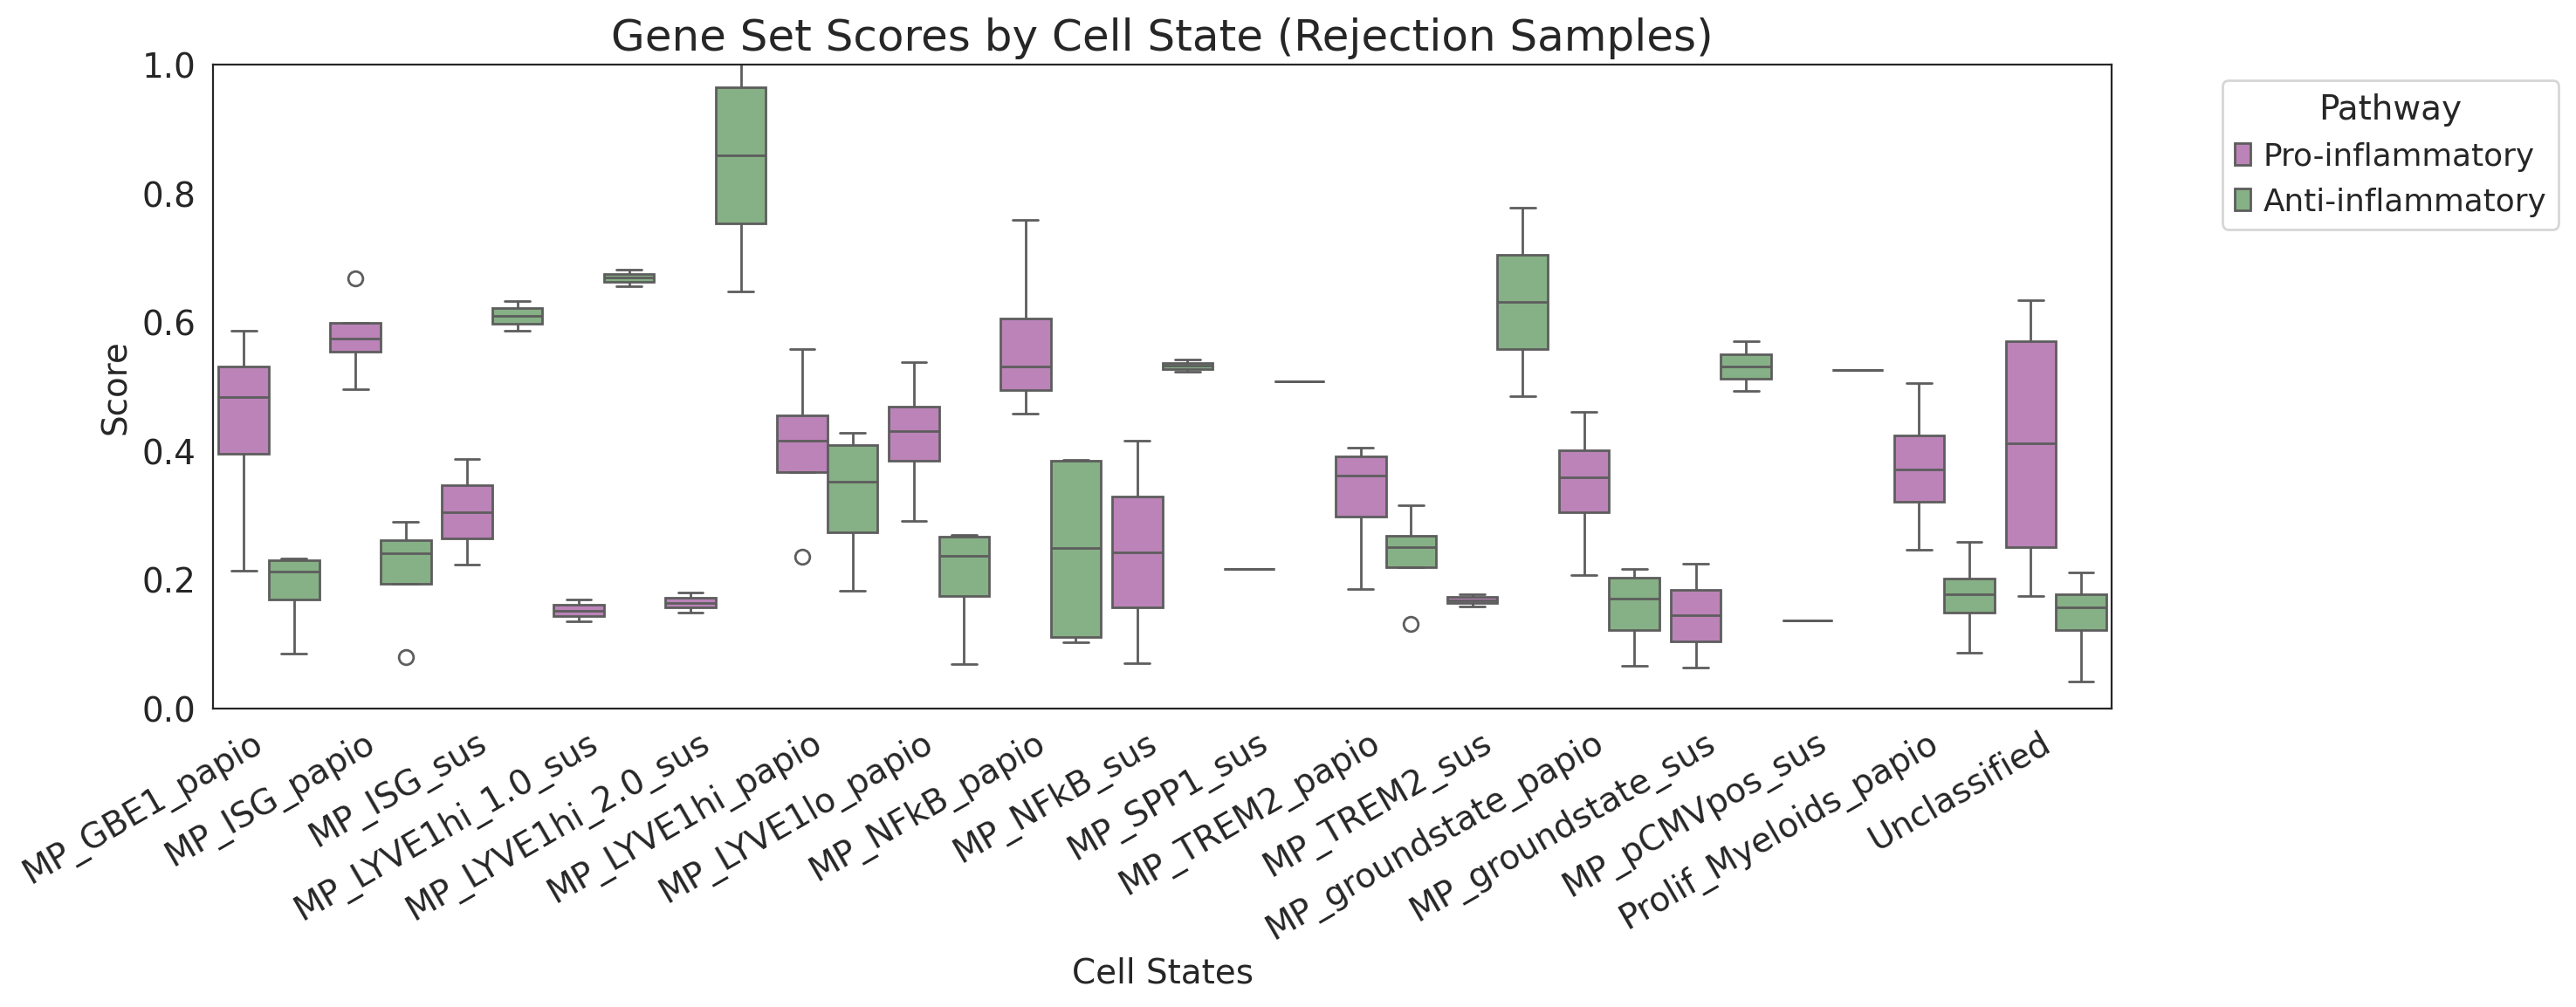

In [36]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For statistical testing
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ===== ADD THIS CRITICAL LINE =====
plt.rcParams['pdf.fonttype'] = 42  # Ensures editable text in PDFs
# ==================================

# User-configurable pathway color palette (muted green & magenta, colorblind-friendly)
pathway_palette = {
    'Pro-inflammatory': '#C47AC0',   # muted magenta
    'Anti-inflammatory': '#7FB77E',  # muted sage green
    # Add more pathways and colors as needed
}

y_axis_limit = 1  # set the maximum y-axis limit here

# Subset adata to only "Per protocol" samples (example: 'Rejection')
adata_pp = adata[adata.obs['Condition_subsets'] == 'Rejection'].copy()

# List of pathway names (e.g., ['Pro-inflammatory', 'Anti-inflammatory'])
# Make sure this matches the columns in your adata.obs
pathways = ['Pro-inflammatory', 'Anti-inflammatory']

# Create DataFrame with scores (only for Per protocol samples)
scores_df = pd.DataFrame()
for pathway_name in pathways:
    score_column = pathway_name + "_score"
    if score_column in adata_pp.obs:
        scores_df[pathway_name] = adata_pp.obs[score_column]

# Add metadata
scores_df['Sample_ID'] = adata_pp.obs['Sample_ID']
scores_df['cell_states'] = adata_pp.obs['cell_states']

# Group by cell state and sample, then take mean (if needed)
state_sample_scores = scores_df.groupby(['cell_states', 'Sample_ID']).mean().reset_index()

# Melt for plotting
state_sample_scores_melted = state_sample_scores.melt(
    id_vars=['cell_states', 'Sample_ID'],
    var_name='Pathway',
    value_name='Score'
)

# --- Statistical Table Function ---
def compute_stats_table_with_samples(state_sample_scores_melted):
    groups = state_sample_scores_melted['cell_states'].unique()
    pathways = state_sample_scores_melted['Pathway'].unique()
    results = []

    for group in groups:
        grp = state_sample_scores_melted[state_sample_scores_melted['cell_states'] == group]
        x = grp[grp['Pathway'] == pathways[0]]['Score'].dropna()
        y = grp[grp['Pathway'] == pathways[1]]['Score'].dropna()
        # Collect Sample_IDs and scores for each pathway
        sample_ids_x = grp[grp['Pathway'] == pathways[0]]['Sample_ID'].tolist()
        sample_ids_y = grp[grp['Pathway'] == pathways[1]]['Sample_ID'].tolist()
        scores_x = x.tolist()
        scores_y = y.tolist()

        if len(x) > 0 and len(y) > 0:
            _, p = mannwhitneyu(x, y, alternative='two-sided')
            mean_x = x.mean()
            mean_y = y.mean()
            log2fc = np.log2(mean_x / mean_y) if mean_y != 0 else np.nan
        else:
            p = np.nan
            log2fc = np.nan

        results.append({
            'cell_states': group,
            'Pathway 1': pathways[0],
            'Pathway 2': pathways[1],
            'p-value': p,
            'Log2 Fold Change': log2fc,
            'Sample_IDs Pathway 1': sample_ids_x,
            'Scores Pathway 1': scores_x,
            'Sample_IDs Pathway 2': sample_ids_y,
            'Scores Pathway 2': scores_y
        })

    # Adjust p-values for multiple testing
    pvals = [r['p-value'] for r in results]
    _, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')
    for i, padj in enumerate(pvals_adj):
        results[i]['Adjusted p-value'] = padj

    return pd.DataFrame(results)

# Generate and display the statistical table
table_df = compute_stats_table_with_samples(state_sample_scores_melted)
display(table_df)

# --- Plotting ---
plt.figure(figsize=(15, 6))
sns.boxplot(
    data=state_sample_scores_melted,
    x='cell_states',  # Cell states on x-axis
    y='Score',
    hue='Pathway',    # Pathways in legend
    palette=pathway_palette,  # Use your custom palette
    width=0.9
)

plt.title('Gene Set Scores by Cell State (Rejection Samples)', fontsize=18)
plt.xlabel('Cell States', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.ylim(0, y_axis_limit)
plt.xticks(rotation=30, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Pathway')
plt.tight_layout()

# -- Save to user-defined path and filename --
# pdf_folder = '/your/path/here/'
# pdf_name = 'GSEA_all_macs_score_per_xaxis_states_legendM1M2_perprotocol.pdf'
# output_path = pdf_folder + pdf_name
# plt.savefig(output_path, format='pdf', bbox_inches='tight', pad_inches=0.1)



# Single Plots for Cell_states 

In [38]:
output_dir = '/data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/GSEA - Different Pathways/Macrophages_Ant_Pro_Inflammatory/Results_Standard_vs_Rejection/'
os.makedirs(output_dir, exist_ok=True)

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker

# --- Utility function to set y-axis ticks in 0.10 steps ---
def set_fixed_yticks(ax, step=0.10, ylimit=None):
    if ylimit is None:
        ylimit = ax.get_ylim()[1]
    ticks = np.arange(0, ylimit + step, step)
    ax.set_yticks(ticks)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# --- Jittered black data points function ---
def plot_jittered_points(ax, data, x_col, y_col, hue_col, order, hue_order, jitter=0.15, size=40, alpha=0.8):
    for i, x_val in enumerate(order):
        for j, hue_val in enumerate(hue_order):
            subset = data[(data[x_col] == x_val) & (data[hue_col] == hue_val)]
            base_x = i
            n_hues = len(hue_order)
            dodge_width = 0.8
            step = dodge_width / n_hues
            start = base_x - dodge_width/2 + step/2
            x_positions = np.random.uniform(start + j*step - jitter/2, start + j*step + jitter/2, size=len(subset))
            ax.scatter(x_positions, subset[y_col], color='black', s=size, alpha=alpha, edgecolor='none', zorder=10)

In [40]:
boxprops = dict(edgecolor='black', linewidth=1.0)
medianprops = dict(color='black', linewidth=1.5)
whiskerprops = dict(color='black', linewidth=1.0)
capprops = dict(color='black', linewidth=1.0)

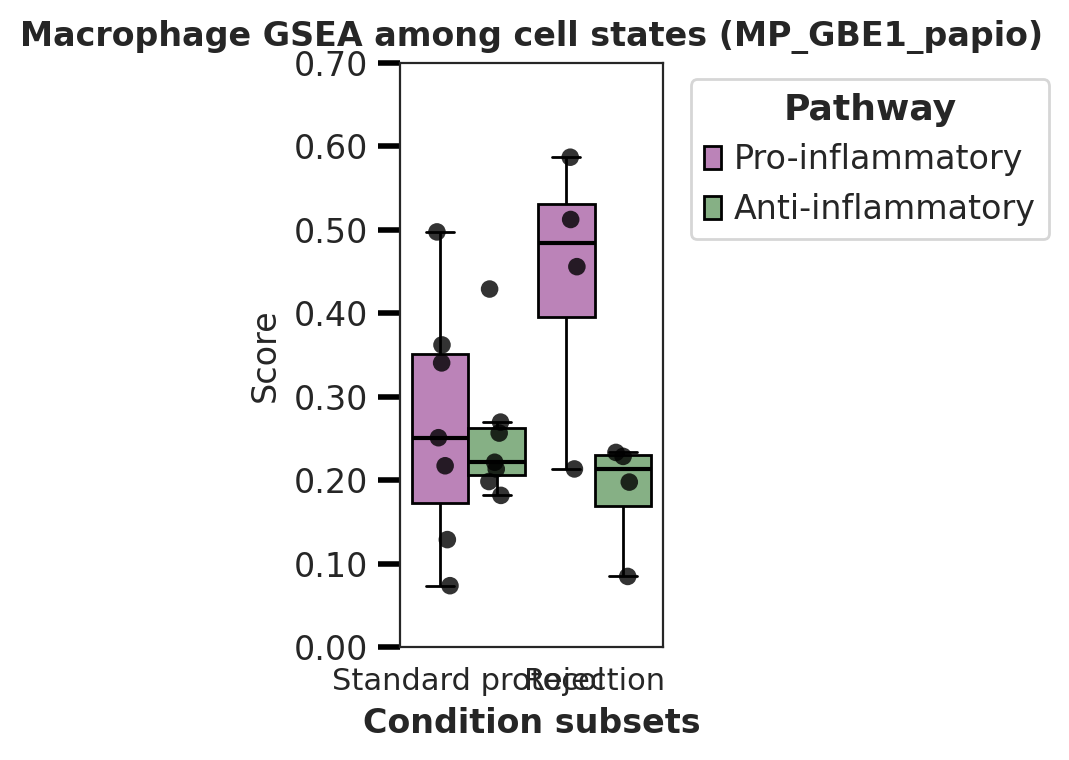

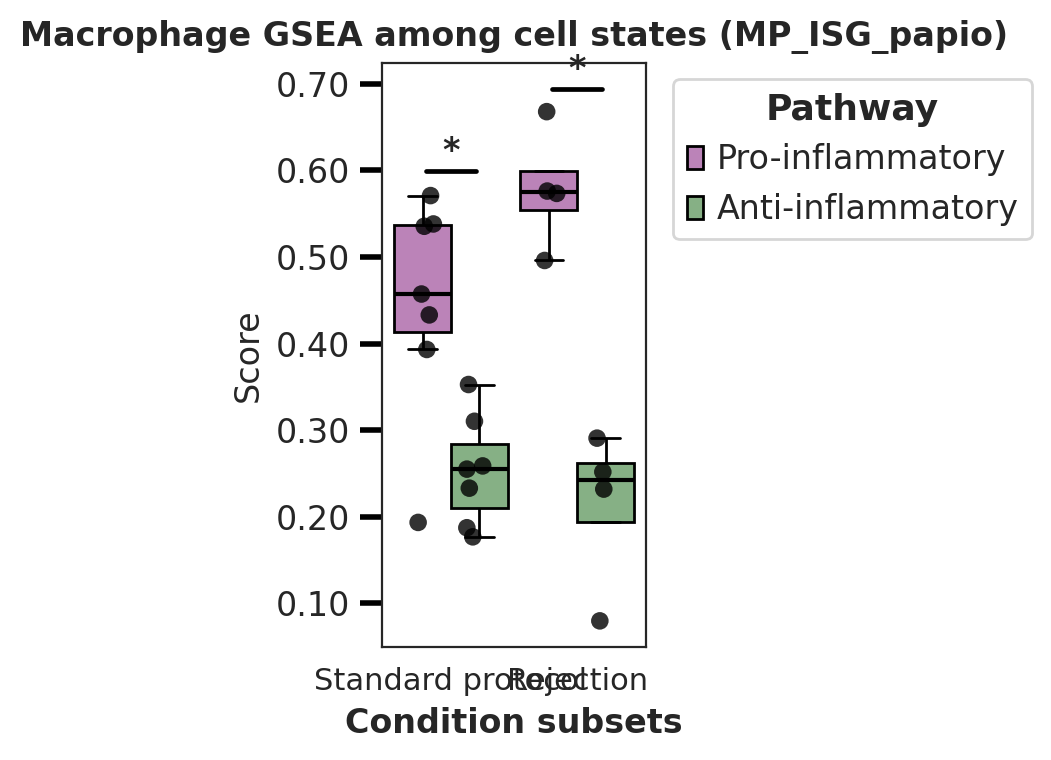

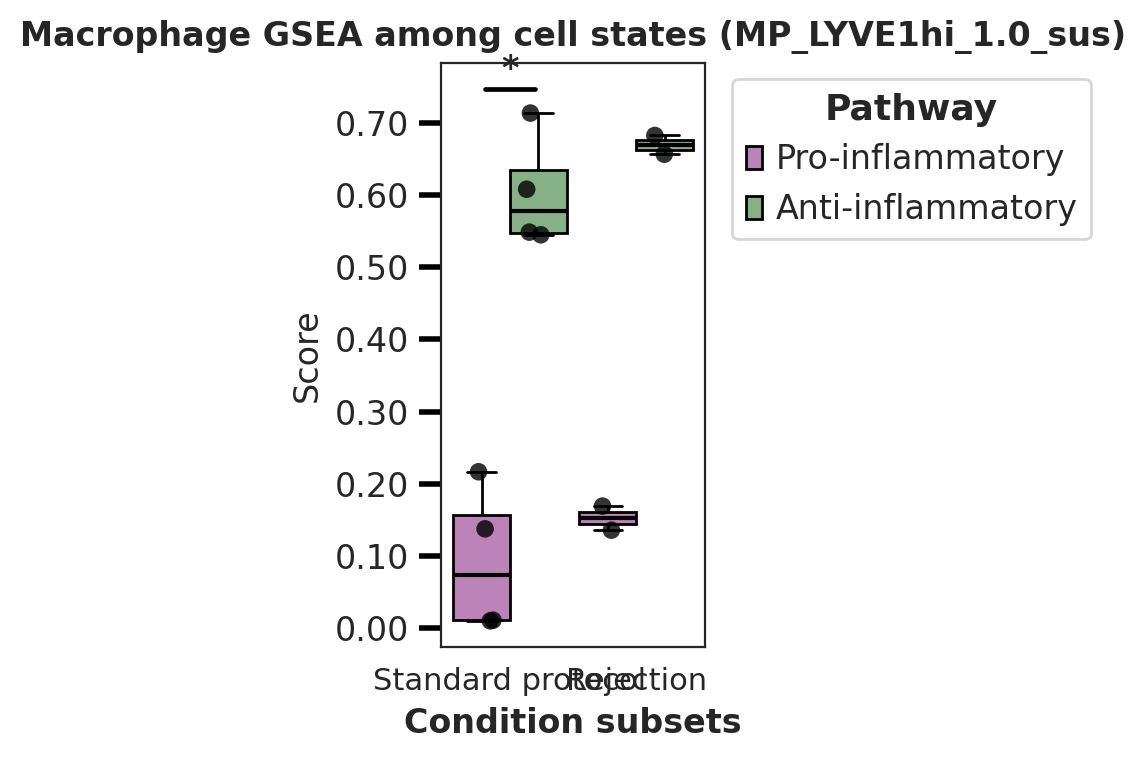

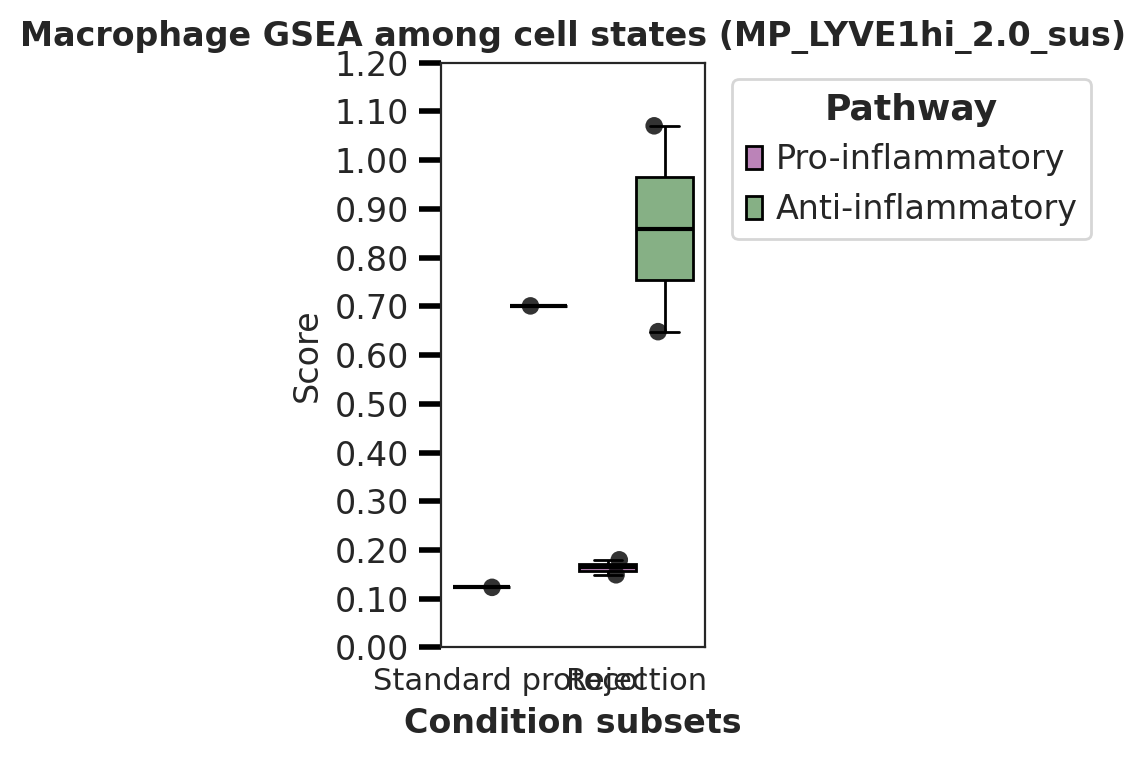

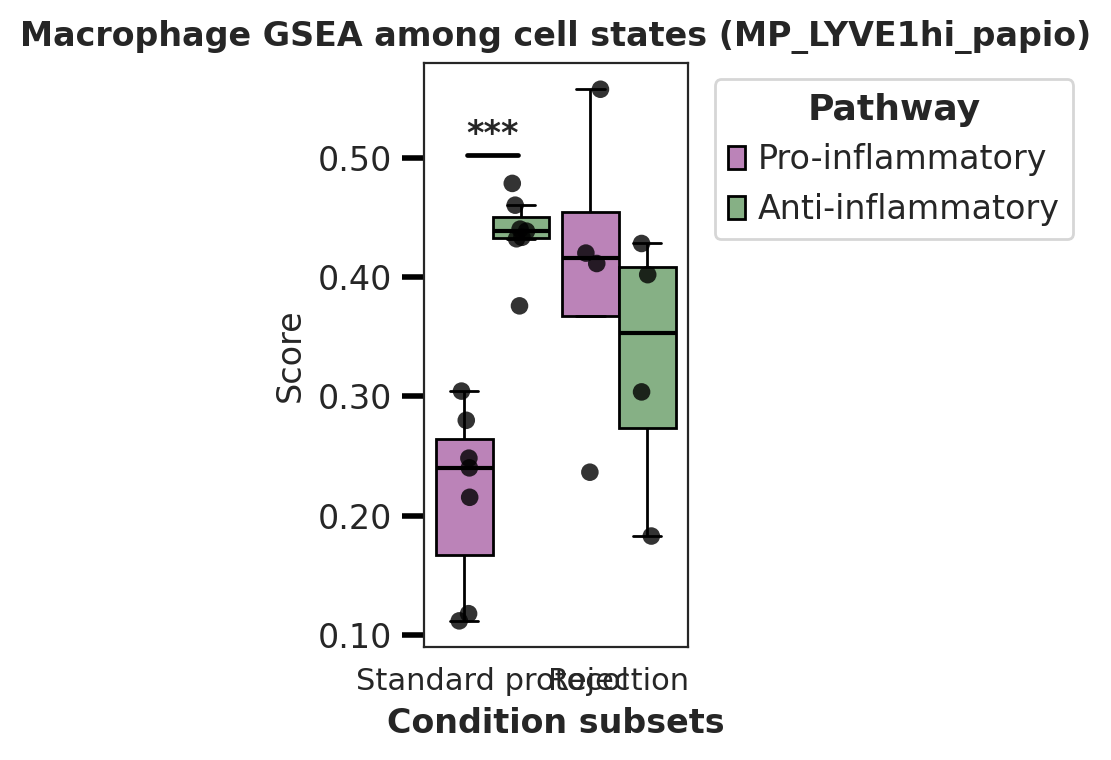

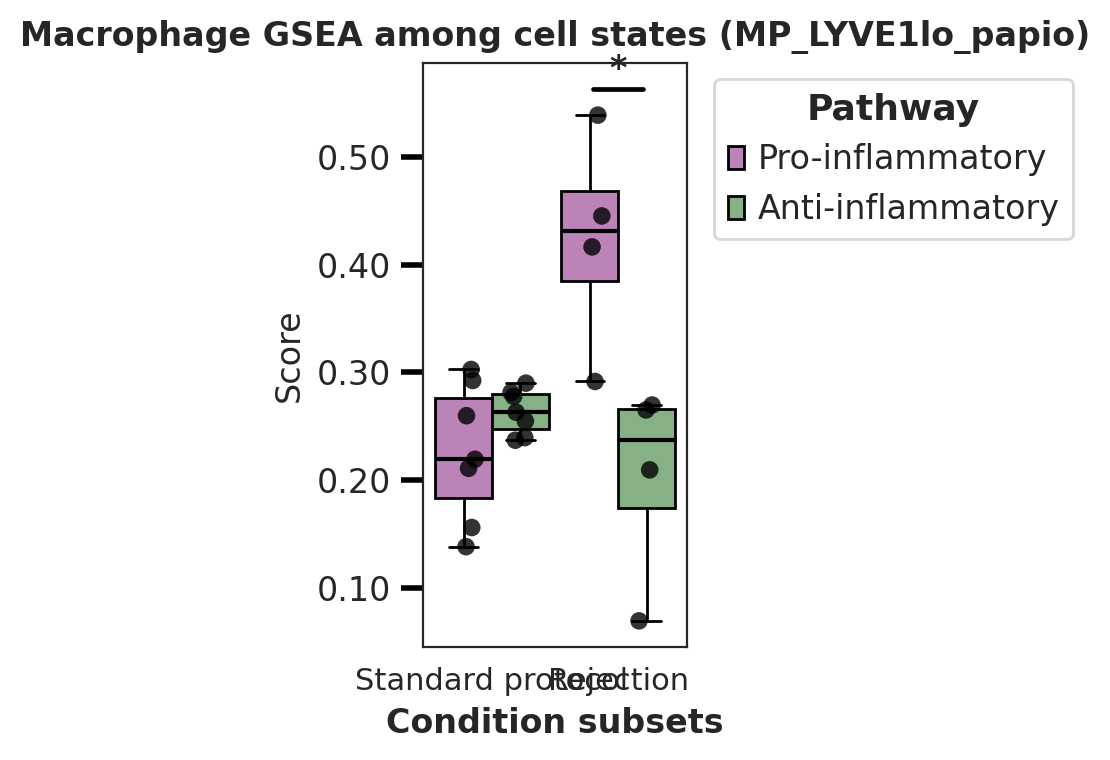

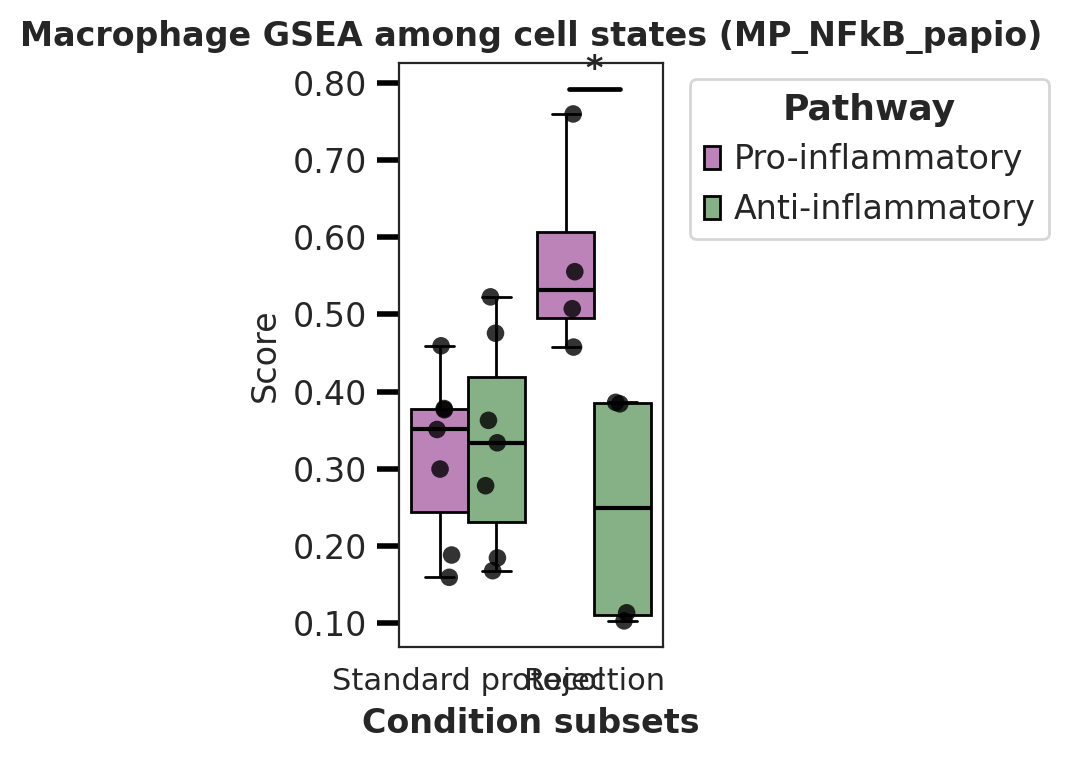

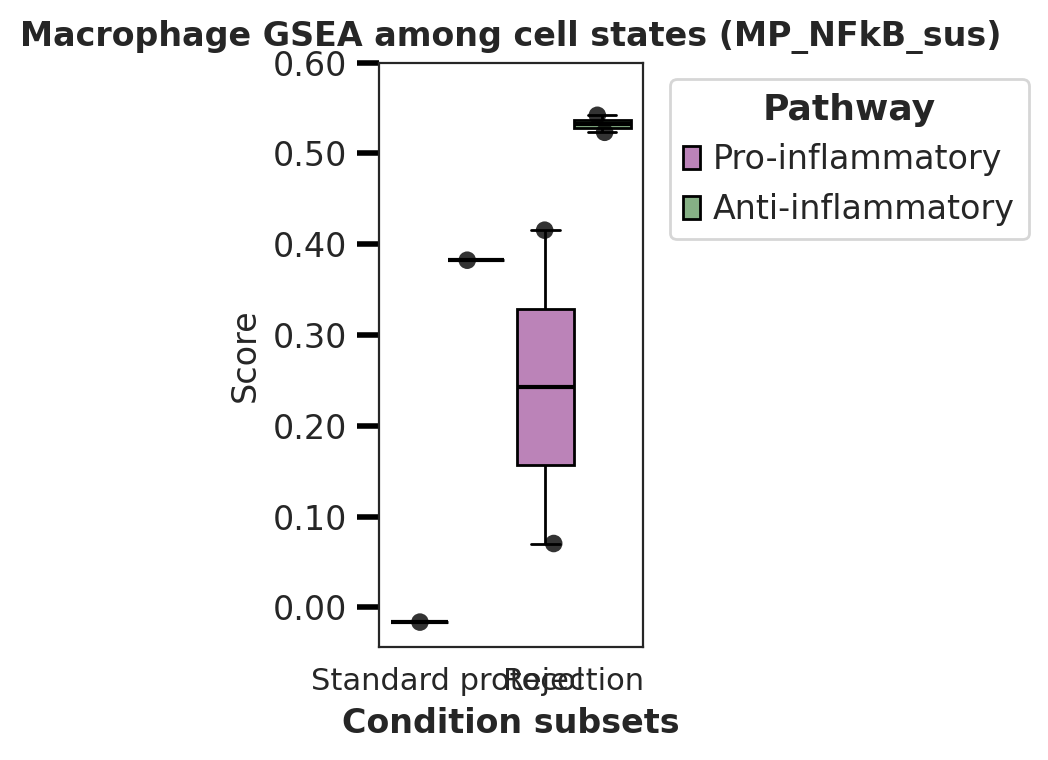

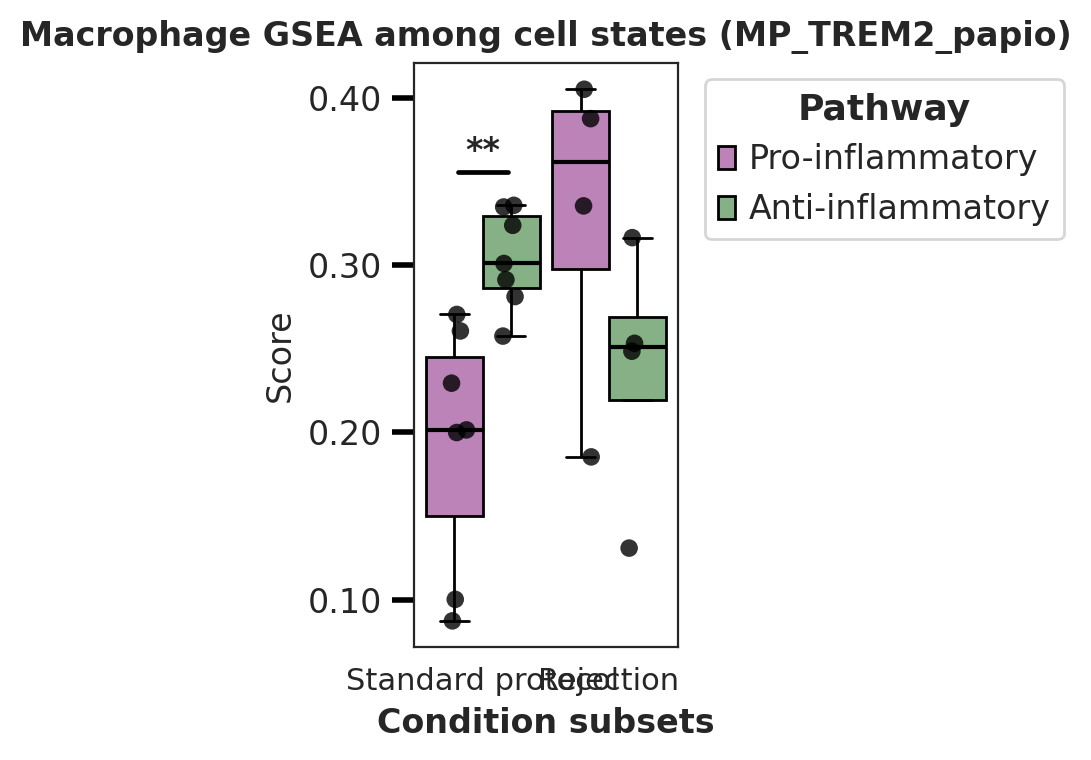

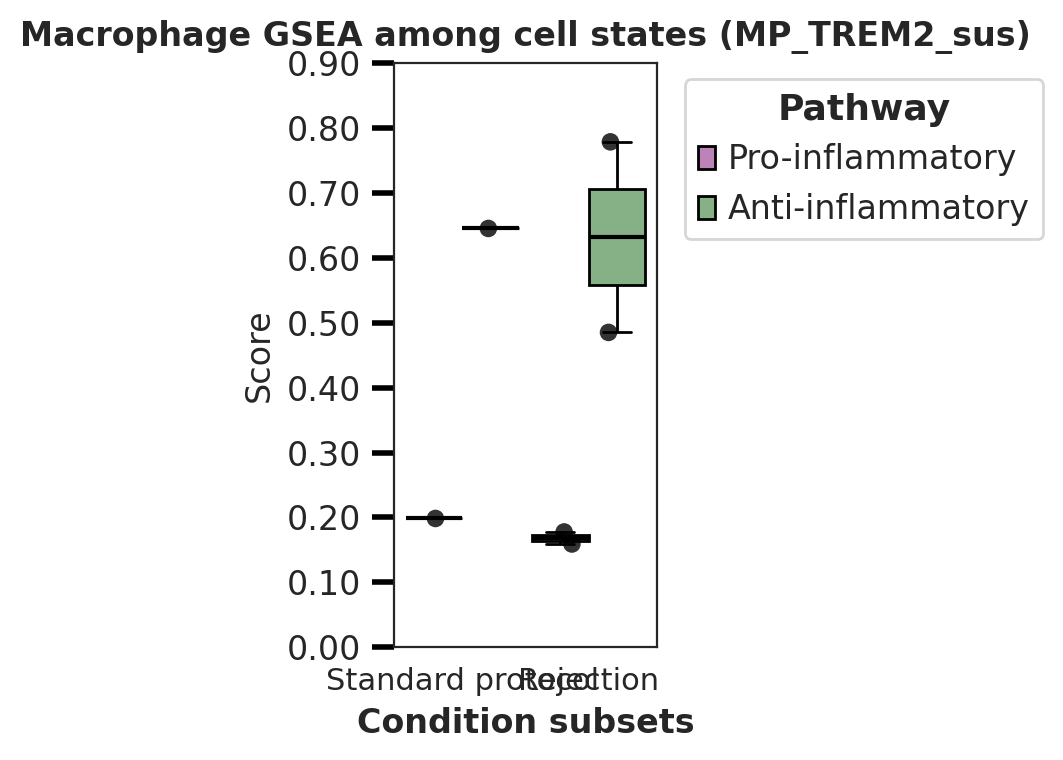

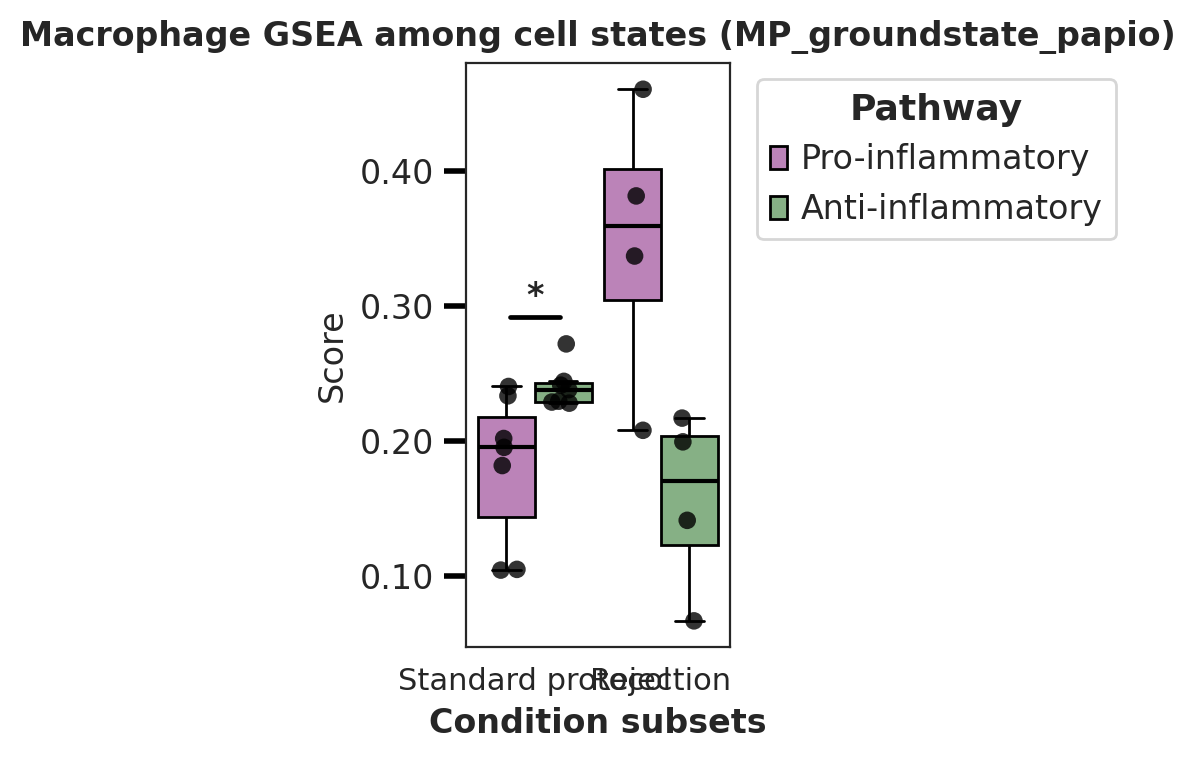

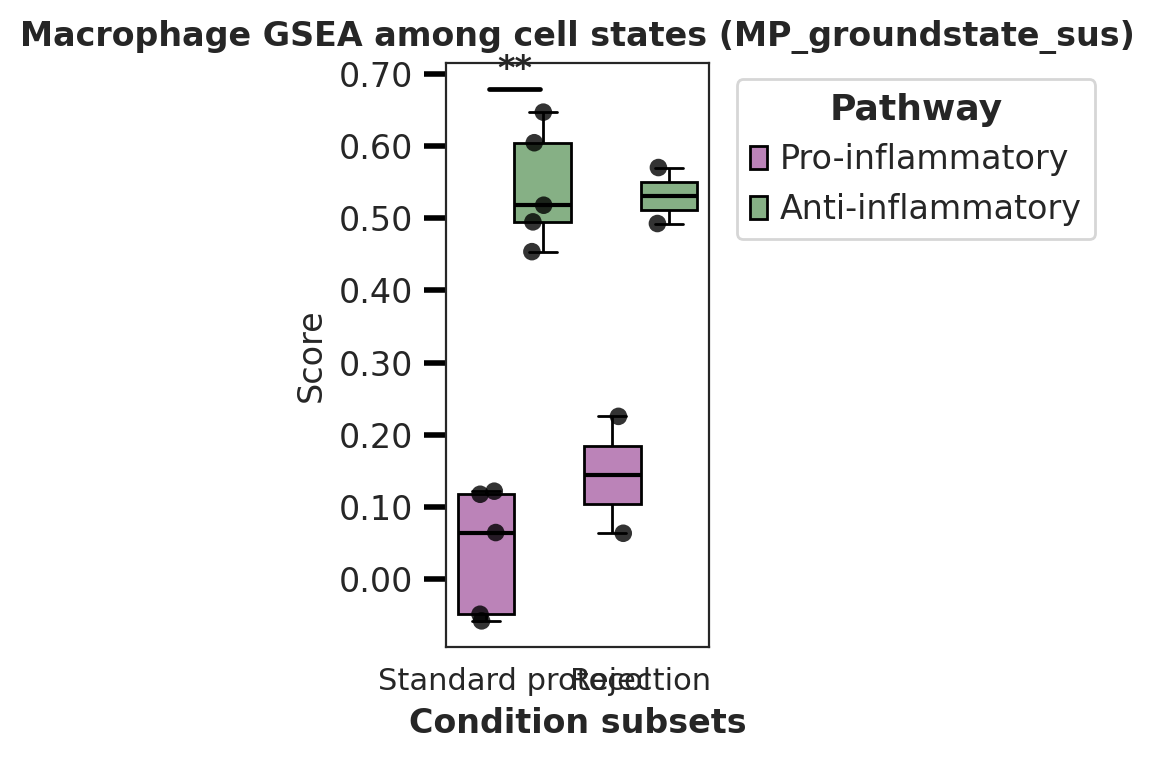

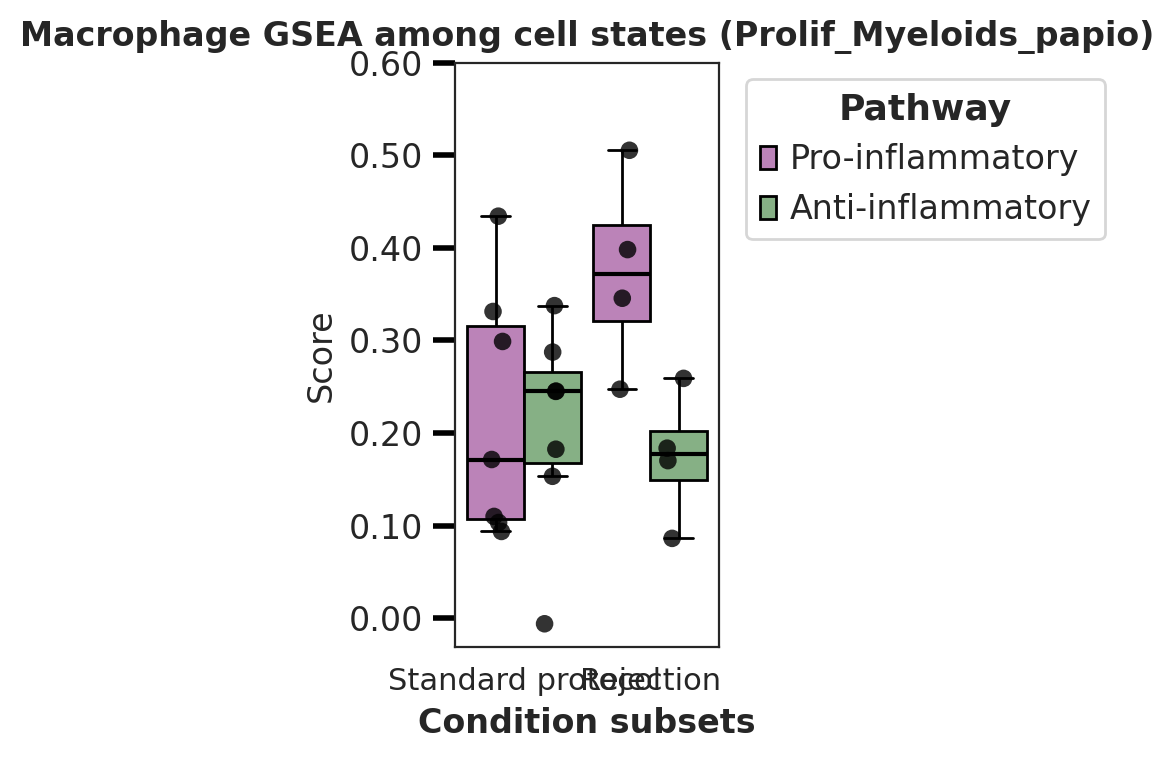

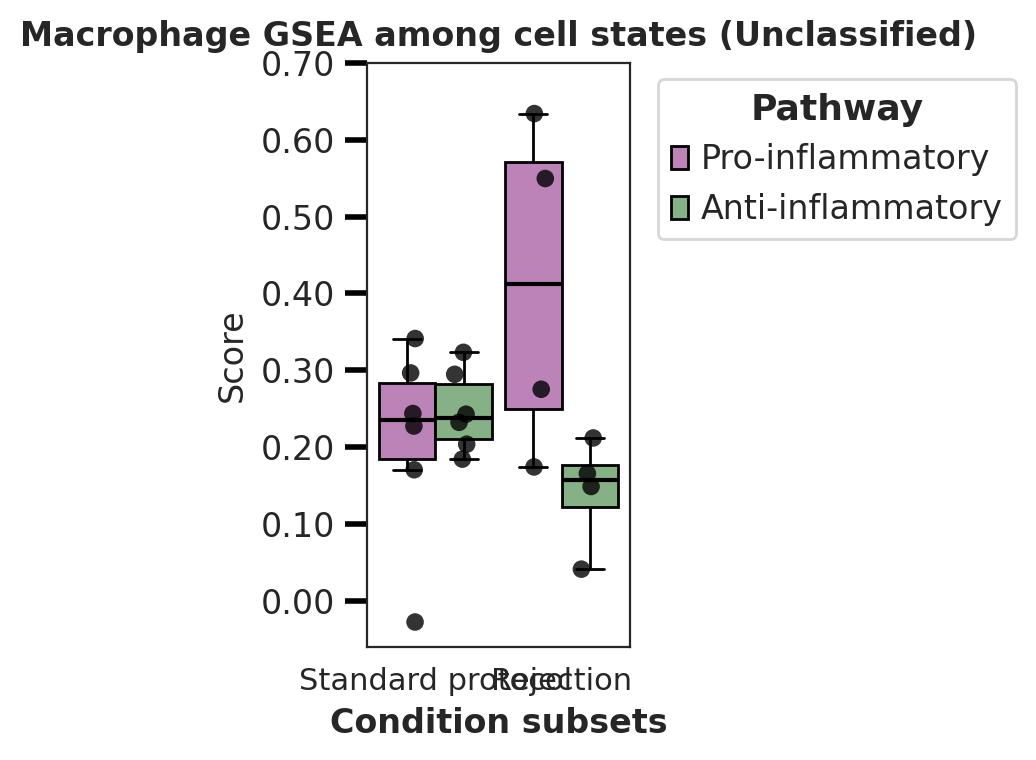

Cell State          Condition               log2FC     p-value    adj p-valueSignificance
MP_GBE1_papio       Standard protocol         0.08      0.9015              1            
MP_GBE1_papio       Rejection                 1.25      0.1143         0.2462            
MP_ISG_papio        Standard protocol         0.82     0.01107        0.07751            
MP_ISG_papio        Rejection                 1.44     0.02857        0.08889            
MP_LYVE1hi_1.0_sus  Standard protocol        -2.69     0.02857        0.08889            
MP_LYVE1hi_1.0_sus  Rejection                -2.14      0.3333         0.4912            
MP_LYVE1hi_2.0_sus  Standard protocol        -2.51           1              1            
MP_LYVE1hi_2.0_sus  Rejection                -2.39      0.3333         0.4912            
MP_LYVE1hi_papio    Standard protocol        -1.01   0.0005828        0.01632           *
MP_LYVE1hi_papio    Rejection                 0.30      0.4857         0.6476            
MP_LYVE1lo

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

# Settings
pathway_order = ['Pro-inflammatory', 'Anti-inflammatory']
custom_palette = {
    'Pro-inflammatory': '#C47AC0',   # muted magenta
    'Anti-inflammatory': '#7FB77E',  # muted sage green
}
condition_order = ['Standard protocol', 'Rejection']

# --- Prepare DataFrame ---
required_columns = [f"{p}_score" for p in pathway_order] + ['Sample_ID', 'cell_states', 'Condition_subsets']
missing = [col for col in required_columns if col not in adata.obs.columns]
if missing:
    raise ValueError(f"Missing columns in adata.obs: {missing}")

scores_df = pd.DataFrame({
    pathway_order[0]: adata.obs[f"{pathway_order[0]}_score"],
    pathway_order[1]: adata.obs[f"{pathway_order[1]}_score"],
    'Sample_ID': adata.obs['Sample_ID'],
    'cell_states': adata.obs['cell_states'],
    'Condition_subsets': adata.obs['Condition_subsets']
})

# Group by (Condition_subsets, cell_states, Sample_ID)
grouped = scores_df.groupby(['Condition_subsets', 'cell_states', 'Sample_ID']).mean(numeric_only=True).reset_index()

# Melt for plotting
melted = grouped.melt(
    id_vars=['Condition_subsets', 'cell_states', 'Sample_ID'],
    value_vars=pathway_order,
    var_name='Pathway',
    value_name='Score'
)

cell_state_order = sorted(melted['cell_states'].dropna().unique())

results = []
all_pvals = []

for cs in cell_state_order:
    data = melted[melted['cell_states'] == cs].copy()
    skip = False
    for cond in condition_order:
        dat = data[data['Condition_subsets'] == cond]
        pro = dat[dat['Pathway'] == pathway_order[0]]['Score'].dropna()
        anti = dat[dat['Pathway'] == pathway_order[1]]['Score'].dropna()
        if pro.empty or anti.empty:
            skip = True
            break
    if skip:
        continue

    plt.figure(figsize=(4.5, 4))
    ax = sns.boxplot(
        data=data,
        x='Condition_subsets',
        y='Score',
        hue='Pathway',
        palette=custom_palette,
        order=condition_order,
        hue_order=pathway_order,
        showfliers=False,
        width=0.9,
        boxprops=boxprops,
        medianprops=medianprops,
        whiskerprops=whiskerprops,
        capprops=capprops
    )

    plot_jittered_points(
        ax, data,
        x_col='Condition_subsets',
        y_col='Score',
        hue_col='Pathway',
        order=condition_order,
        hue_order=pathway_order,
        jitter=0.15,
        size=40,
        alpha=0.8
    )

    ax.yaxis.set_ticks_position('left')
    ax.tick_params(axis='y', which='major', length=8, width=2, color='black', direction='out', labelsize=15)
    ax.tick_params(axis='y', which='minor', length=0)
    set_fixed_yticks(ax, step=0.10)

    # Collect p-values and log2fc for adjustment
    for i, cond in enumerate(condition_order):
        dat = data[data['Condition_subsets'] == cond]
        pro = dat[dat['Pathway'] == pathway_order[0]]['Score'].dropna()
        anti = dat[dat['Pathway'] == pathway_order[1]]['Score'].dropna()
        if not pro.empty and not anti.empty:
            stat, p = mannwhitneyu(pro, anti, alternative='two-sided')
            mean_pro = pro.mean()
            mean_anti = anti.mean()
            log2fc = np.log2(mean_pro / mean_anti) if mean_anti != 0 else np.nan
            results.append({
                'cell_state': cs,
                'condition': cond,
                'pval': p,
                'log2fc': log2fc
            })
            all_pvals.append(p)
        else:
            results.append({
                'cell_state': cs,
                'condition': cond,
                'pval': np.nan,
                'log2fc': np.nan
            })

        # Plot significance stars (using raw p-value)
        if not pro.empty and not anti.empty:
            if p < 0.001:
                stars = '***'
            elif p < 0.01:
                stars = '**'
            elif p < 0.05:
                stars = '*'
            else:
                stars = ''
            if stars:
                y_max1 = pro.max()
                y_max2 = anti.max()
                y_max = max(y_max1, y_max2)
                ylim = ax.get_ylim()
                y_range = ylim[1] - ylim[0]
                offset = 0.04 * y_range if y_range != 0 else 0.04
                y = y_max + offset
                box_offset = 0.2
                x1 = i - box_offset
                x2 = i + box_offset
                ax.plot([x1, x2], [y, y], c='k', lw=1.7)
                ax.text(i, y + offset * 0.13, stars, ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.title(f'Macrophage GSEA among cell states ({cs})', fontsize=12, fontweight='bold')
    plt.xlabel('Condition subsets', fontsize=12, fontweight='bold')
    plt.ylabel('Score', fontsize=12)
    plt.xticks(rotation=0, ha='center', fontsize=11)
    plt.yticks(fontsize=12)
    legend = plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left', fontsize=12, title='Pathway')
    plt.setp(legend.get_title(), fontsize=13, fontweight='bold')
    plt.tight_layout()
    # --- Save each plot as a PDF with the cell state name ---
    cell_state_clean = cs.replace(' ', '_').replace('/', '_')
    pdf_path = os.path.join(output_dir, f"{cell_state_clean}.pdf")
    plt.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()

# Adjust p-values (Benjamini-Hochberg)
if all_pvals:
    _, adj_pvals, _, _ = multipletests(all_pvals, alpha=0.05, method='fdr_bh')
else:
    adj_pvals = []

# Assign adjusted p-values back to results
adj_idx = 0
for res in results:
    if not np.isnan(res['pval']):
        res['adj_pval'] = adj_pvals[adj_idx]
        adj_idx += 1
    else:
        res['adj_pval'] = np.nan

# Print summary table
print(f"{'Cell State':<20}{'Condition':<20}{'log2FC':>10}{'p-value':>12}{'adj p-value':>15}{'Significance':>12}")
for res in results:
    if not np.isnan(res['pval']):
        sig = ''
        if res['adj_pval'] < 0.001:
            sig = '***'
        elif res['adj_pval'] < 0.01:
            sig = '**'
        elif res['adj_pval'] < 0.05:
            sig = '*'
        print(f"{res['cell_state']:<20}{res['condition']:<20}{res['log2fc']:>10.2f}{res['pval']:>12.4g}{res['adj_pval']:>15.4g}{sig:>12}")
    else:
        print(f"{res['cell_state']:<20}{res['condition']:<20}{'NA':>10}{'NA':>12}{'NA':>15}{'':>12}")

# Optional: Save results to CSV
# pd.DataFrame(results).to_csv('gsea_results_summary.csv', index=False)


In [ ]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame with gene set scores and cell state & sample info
scores_df = pd.DataFrame()

for pathway_name in pathways:
    score_column = pathway_name + "_score"
    if score_column in adata.obs:
        scores_df[score_column] = adata.obs[score_column]

# Add sample and cell state info
scores_df['Sample_ID'] = adata.obs['Sample_ID']
scores_df['cell_states'] = adata.obs['cell_states']

# Group by Sample_ID and Cell_State and compute mean
state_sample_scores = scores_df.groupby(['cell_states', 'Sample_ID']).mean().reset_index()

# Melt for plotting
state_sample_scores_melted = state_sample_scores.melt(
    id_vars=['cell_states', 'Sample_ID'],
    var_name='Pathway',
    value_name='Score'
)

# --- Plot 1: Boxplot of gene set scores by Cell_State ---
plt.figure(figsize=(20, 8))
sns.boxplot(
    data=state_sample_scores_melted,
    x='Pathway',
    y='Score',
    hue='cell_states',
    palette='Paired',
    width=0.9 
)

plt.title('Sample-Aggregated Gene Set Scores by Pathways percell_states', fontsize=18)
plt.xlabel('Pathway', fontsize=14, rotation=0)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='cell_states')
plt.tight_layout()
plt.show()


In [ ]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===== ADD THIS CRITICAL LINE =====
plt.rcParams['pdf.fonttype'] = 42  # Ensures editable text in PDFs
# ==================================

# -- Your data prep code here --
scores_df = pd.DataFrame()
for pathway_name in pathways:
    score_column = pathway_name + "_score"
    if score_column in adata.obs:
        scores_df[score_column] = adata.obs[score_column]
scores_df['Sample_ID'] = adata.obs['Sample_ID']
scores_df['cell_states'] = adata.obs['cell_states']
state_sample_scores = scores_df.groupby(['cell_states', 'Sample_ID']).mean().reset_index()
state_sample_scores_melted = state_sample_scores.melt(
    id_vars=['cell_states', 'Sample_ID'],
    var_name='Pathway',
    value_name='Score'
)

# -- Plotting --
plt.figure(figsize=(20, 8))
sns.boxplot(
    data=state_sample_scores_melted,
    x='Pathway',
    y='Score',
    hue='cell_states',
    palette='Paired',
    width=0.9 
)
plt.title('Sample-Aggregated Gene Set Scores by Pathways percell_states', fontsize=18)
plt.xlabel('Pathway', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='cell_states')
plt.tight_layout()

# -- Save to user-defined path and filename --
pdf_folder = '/data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/GSEA_Immune_Cells/GSEA_M1_M2_pol_RESULTS/'  # Optional
pdf_name = 'GSEA_by_cell_states_all_macrophages_score_per_state.pdf'  # Change this to your desired filename
output_path = pdf_folder + pdf_name  # Or just output_path = 'your_full_path.pdf'
plt.savefig(output_path, format='pdf', bbox_inches='tight', pad_inches=0.1)

plt.show()


In [ ]:
# ===== ADD THIS CRITICAL LINE =====
plt.rcParams['pdf.fonttype'] = 42  # Ensures editable text in PDFs
# ==================================


# Subset adata to only "Per protocol" samples
adata_pp = adata[adata.obs['Conditions'] == 'Per protocol'].copy()

# Create DataFrame with scores (only for Per protocol samples)
scores_df = pd.DataFrame()

for pathway_name in pathways:
    score_column = pathway_name + "_score"
    if score_column in adata_pp.obs:
        scores_df[score_column] = adata_pp.obs[score_column]

# Add metadata
scores_df['Sample_ID'] = adata_pp.obs['Sample_ID']
scores_df['cell_states'] = adata_pp.obs['cell_states']

# Group by cell state and sample, then take mean
state_sample_scores = scores_df.groupby(['cell_states', 'Sample_ID']).mean().reset_index()

# Melt for plotting
state_sample_scores_melted = state_sample_scores.melt(
    id_vars=['cell_states', 'Sample_ID'],
    var_name='Pathway',
    value_name='Score'
)

plt.figure(figsize=(20, 8))
sns.boxplot(
    data=state_sample_scores_melted,
    x='cell_states',  # Cell states on x-axis
    y='Score',
    hue='Pathway',    # Pathways in legend
    palette='Paired',
    width=0.9
)

plt.title('Gene Set Scores by Cell State (Per Protocol Samples)', fontsize=18)
plt.xlabel('Cell States', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Pathway')
plt.tight_layout()

# -- Save to user-defined path and filename --
pdf_folder = '/data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/GSEA_Immune_Cells/GSEA_M1_M2_pol_RESULTS/'  # Optional
pdf_name = 'GSEA_all_macs_score_per_xaxis_states_legendM1M2_perprotocol.pdf'  # Change this to your desired filename
output_path = pdf_folder + pdf_name  # Or just output_path = 'your_full_path.pdf'
plt.savefig(output_path, format='pdf', bbox_inches='tight', pad_inches=0.1)

plt.show()

In [ ]:
# ===== ADD THIS CRITICAL LINE =====
plt.rcParams['pdf.fonttype'] = 42  # Ensures editable text in PDFs
# ==================================


# Subset adata to only "Per protocol" samples
adata_pp = adata[adata.obs['Conditions'] == 'Rejection'].copy()

# Create DataFrame with scores (only for Per protocol samples)
scores_df = pd.DataFrame()

for pathway_name in pathways:
    score_column = pathway_name + "_score"
    if score_column in adata_pp.obs:
        scores_df[score_column] = adata_pp.obs[score_column]

# Add metadata
scores_df['Sample_ID'] = adata_pp.obs['Sample_ID']
scores_df['cell_states'] = adata_pp.obs['cell_states']

# Group by cell state and sample, then take mean
state_sample_scores = scores_df.groupby(['cell_states', 'Sample_ID']).mean().reset_index()

# Melt for plotting
state_sample_scores_melted = state_sample_scores.melt(
    id_vars=['cell_states', 'Sample_ID'],
    var_name='Pathway',
    value_name='Score'
)

plt.figure(figsize=(20, 8))
sns.boxplot(
    data=state_sample_scores_melted,
    x='cell_states',  # Cell states on x-axis
    y='Score',
    hue='Pathway',    # Pathways in legend
    palette='Paired',
    width=0.9
)

plt.title('Gene Set Scores by Cell State (Rejection Samples)', fontsize=18)
plt.xlabel('Cell States', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Pathway')
plt.tight_layout()

# -- Save to user-defined path and filename --
pdf_folder = '/data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/GSEA_Immune_Cells/GSEA_M1_M2_pol_RESULTS/'  # Optional
pdf_name = 'GSEA_all_macs_score_per_xaxis_states_legendM1M2_rejection.pdf'  # Change this to your desired filename
output_path = pdf_folder + pdf_name  # Or just output_path = 'your_full_path.pdf'
plt.savefig(output_path, format='pdf', bbox_inches='tight', pad_inches=0.1)

plt.show()

In [ ]:
# Subset for only MP_ISG_papio cells and the two conditions we want
adata_mp_isg = adata[
    (adata.obs['cell_states'] == 'MP_ISG_papio') & 
    (adata.obs['Conditions'].isin(['Per protocol', 'Rejection']))
].copy()

# Create DataFrame with scores
scores_df = pd.DataFrame()
for pathway_name in pathways:
    score_column = pathway_name + "_score"
    if score_column in adata_mp_isg.obs:
        scores_df[score_column] = adata_mp_isg.obs[score_column]

# Add metadata
scores_df['Sample_ID'] = adata_mp_isg.obs['Sample_ID']
scores_df['Conditions'] = adata_mp_isg.obs['Conditions']

# Group by Condition and Sample, then take mean
condition_sample_scores = scores_df.groupby(['Conditions', 'Sample_ID']).median().reset_index()

# Melt for plotting
melted_scores = condition_sample_scores.melt(
    id_vars=['Conditions', 'Sample_ID'],
    var_name='Pathway',
    value_name='Score'
)

# Create the plot with explicit condition filtering
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=melted_scores,
    x='Pathway',
    y='Score',
    hue='Conditions',
    hue_order=['Per protocol', 'Rejection'],  # Explicitly specify which conditions to show
    palette={'Per protocol': 'skyblue', 'Rejection': 'salmon'},
    width=0.8
)

plt.title('Pathway Scores in MP_ISG_papio Cells\nPer Protocol vs Rejection', fontsize=16)
plt.xlabel('Pathway', fontsize=14)
plt.ylabel('Gene Set Score', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Condition', bbox_to_anchor=(1.0, 1))
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np

# List of unique pathways
pathways_list = melted_scores['Pathway'].unique()
pvals = []

for pathway in pathways_list:
    group1 = melted_scores[(melted_scores['Pathway'] == pathway) & (melted_scores['Conditions'] == 'Per protocol')]['Score'].dropna()
    group2 = melted_scores[(melted_scores['Pathway'] == pathway) & (melted_scores['Conditions'] == 'Rejection')]['Score'].dropna()
    # If either group is empty, skip (to avoid errors)
    if len(group1) == 0 or len(group2) == 0:
        pval = np.nan
    else:
        stat, pval = mannwhitneyu(group1, group2, alternative='two-sided')
    pvals.append(pval)

# Adjust p-values for multiple testing (FDR)
pvals_adj = multipletests(pvals, method='fdr_bh')[1]

# Build results DataFrame
stats_df = pd.DataFrame({
    'Pathway': pathways_list,
    'p-value': pvals,
    'FDR': pvals_adj
}).sort_values('p-value')

print(stats_df)

plt.figure(figsize=(15, 8))
ax = sns.boxplot(
    data=melted_scores,
    x='Pathway',
    y='Score',
    hue='Conditions',
    hue_order=['Per protocol', 'Rejection'],
    palette={'Per protocol': 'skyblue', 'Rejection': 'salmon'},
    width=0.8
)

plt.title('Pathway Scores in MP_ISG_papio Cells\nPer Protocol vs Rejection', fontsize=16)
plt.xlabel('Pathway', fontsize=14)
plt.ylabel('Gene Set Score', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Condition', bbox_to_anchor=(1, 1))
plt.tight_layout()

# Annotate with FDR-corrected p-values (optional: only those <0.05)
for i, pathway in enumerate(stats_df['Pathway']):
    pval = stats_df.loc[stats_df['Pathway'] == pathway, 'FDR'].values[0]
    y_max = melted_scores[melted_scores['Pathway'] == pathway]['Score'].max()
    annotation = ""
    if pval < 0.001:
        annotation = '***'
    elif pval < 0.01:
        annotation = '**'
    elif pval < 0.05:
        annotation = '*'
    if annotation:
        ax.text(i, y_max + 0.1, annotation, ha='center', va='bottom', color='k', fontsize=18)

plt.show()


In [ ]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np

# List of unique pathways
pathways_list = melted_scores['Pathway'].unique()
pvals = []

for pathway in pathways_list:
    group1 = melted_scores[(melted_scores['Pathway'] == pathway) & (melted_scores['Conditions'] == 'Per protocol')]['Score'].dropna()
    group2 = melted_scores[(melted_scores['Pathway'] == pathway) & (melted_scores['Conditions'] == 'Rejection')]['Score'].dropna()
    # If either group is empty, skip (to avoid errors)
    if len(group1) == 0 or len(group2) == 0:
        pval = np.nan
    else:
        stat, pval = mannwhitneyu(group1, group2, alternative='two-sided')
    pvals.append(pval)

# Adjust p-values for multiple testing (FDR)
pvals_adj = multipletests(pvals, method='fdr_bh')[1]

# Build results DataFrame
stats_df = pd.DataFrame({
    'Pathway': pathways_list,
    'p-value': pvals,
    'FDR': pvals_adj
}).sort_values('p-value')

print(stats_df)

plt.figure(figsize=(15, 8))
ax = sns.boxplot(
    data=melted_scores,
    x='Pathway',
    y='Score',
    hue='Conditions',
    hue_order=['Per protocol', 'Rejection'],
    palette={'Per protocol': 'skyblue', 'Rejection': 'salmon'},
    width=0.8
)

plt.title('Pathway Scores in MP_ISG_papio Cells\nPer Protocol vs Rejection', fontsize=16)
plt.xlabel('Pathway', fontsize=14)
plt.ylabel('Gene Set Score', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Condition', bbox_to_anchor=(1, 1))
plt.tight_layout()

# Annotate with FDR-corrected p-values (optional: only those <0.05)
for i, pathway in enumerate(stats_df['Pathway']):
    pval = stats_df.loc[stats_df['Pathway'] == pathway, 'FDR'].values[0]
    y_max = melted_scores[melted_scores['Pathway'] == pathway]['Score'].max()
    annotation = ""
    if pval < 0.001:
        annotation = '***'
    elif pval < 0.01:
        annotation = '**'
    elif pval < 0.05:
        annotation = '*'
    if annotation:
        ax.text(i, y_max + 0.1, annotation, ha='center', va='bottom', color='k', fontsize=18)

plt.show()


# Styling boxplots 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import os

# ===== ADD THIS CRITICAL LINE =====
plt.rcParams['pdf.fonttype'] = 42  # Ensures editable text in PDFs
# ==================================

# =====================
# CONFIGURATION SETTINGS
# =====================
OUTPUT_PATH = '/data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/GSEA_Immune_Cells/GSEA_M1_M2_pol_RESULTS/'
BOX_WIDTH = 0.9
FONT_SIZE = 12
PALETTE = {'Per protocol': 'skyblue', 'Rejection': 'salmon'}
DPI = 300
FIGURE_SIZE = (8, 6)

# =====================
# DATA PROCESSING FUNCTION
# =====================
def prepare_data(cell_state, adata, pathways):
    adata_sub = adata[
        (adata.obs['cell_states'] == cell_state) & 
        (adata.obs['Conditions'].isin(['Per protocol', 'Rejection']))
    ].copy()
    
    if len(adata_sub) == 0:
        print(f"No data found for cell state: {cell_state}")
        return None
    
    scores_df = pd.DataFrame()
    for pathway_name in pathways:
        score_column = f"{pathway_name}_score"
        if score_column in adata_sub.obs:
            scores_df[score_column] = adata_sub.obs[score_column]
    
    scores_df['Sample_ID'] = adata_sub.obs['Sample_ID']
    scores_df['Conditions'] = adata_sub.obs['Conditions']
    
    condition_sample_scores = scores_df.groupby(['Conditions', 'Sample_ID']).median().reset_index()
    
    melted_scores = condition_sample_scores.melt(
        id_vars=['Conditions', 'Sample_ID'],
        var_name='Pathway',
        value_name='Score'
    )
    return melted_scores

# =====================
# STATISTICAL ANALYSIS FUNCTION
# =====================
def run_stats(melted_scores):
    pathways_list = melted_scores['Pathway'].unique()
    pvals = []
    
    for pathway in pathways_list:
        group1 = melted_scores[
            (melted_scores['Pathway'] == pathway) & 
            (melted_scores['Conditions'] == 'Per protocol')
        ]['Score'].dropna()
        
        group2 = melted_scores[
            (melted_scores['Pathway'] == pathway) & 
            (melted_scores['Conditions'] == 'Rejection')
        ]['Score'].dropna()
        
        if len(group1) > 0 and len(group2) > 0:
            try:
                _, pval = mannwhitneyu(group1, group2, alternative='two-sided')
            except:
                pval = np.nan
        else:
            pval = np.nan
        pvals.append(pval)
    
    pvals_valid = [p for p in pvals if not np.isnan(p)]
    pvals_adj = multipletests(pvals_valid, method='fdr_bh')[1]
    
    pvals_adj_full = []
    adj_idx = 0
    for p in pvals:
        if np.isnan(p):
            pvals_adj_full.append(np.nan)
        else:
            pvals_adj_full.append(pvals_adj[adj_idx])
            adj_idx += 1
    
    stats_df = pd.DataFrame({
        'Pathway': pathways_list,
        'p-value': pvals,
        'FDR': pvals_adj_full
    })
    return stats_df

# =====================
# PLOTTING FUNCTION (with y-axis label option)
# =====================
def plot_pathway_scores(cell_state, melted_scores, stats_df, save_plot=True, y_label='Gene Set Score'):
    plt.rcParams.update({
        'font.size': FONT_SIZE,
        'axes.titlesize': FONT_SIZE,
        'axes.labelsize': FONT_SIZE,
        'xtick.labelsize': FONT_SIZE,
        'ytick.labelsize': FONT_SIZE,
        'legend.fontsize': FONT_SIZE,
        'legend.title_fontsize': FONT_SIZE,
        'font.weight': 'bold',
        'axes.labelweight': 'bold',
        'axes.titleweight': 'bold',
        'figure.dpi': DPI,
        'savefig.dpi': DPI,
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans']
    })
    
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    
    sns.boxplot(
        data=melted_scores,
        x='Pathway',
        y='Score',
        hue='Conditions',
        hue_order=['Per protocol', 'Rejection'],
        palette=PALETTE,
        width=BOX_WIDTH,
        linewidth=1.5,
        ax=ax,
        fliersize=3,
        showfliers=False  # Hide default outliers
    )
    # Overlay stripplot for individual samples (black dots)
    sns.stripplot(
        data=melted_scores,
        x='Pathway',
        y='Score',
        hue='Conditions',
        hue_order=['Per protocol', 'Rejection'],
        palette=['black', 'black'],  # Both groups as black
        dodge=True,                   # Aligns dots with boxplot groups
        jitter=0.2,                   # Slight jitter to prevent overlap
        ax=ax,
        size=4,                       # Dot size
        marker='o',
        edgecolor='none',
        alpha=0.6,
        legend=None
    )

    # To avoid duplicate legends, remove the stripplot legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Conditions', loc='upper right',
              title_fontsize=FONT_SIZE, fontsize=FONT_SIZE,
              frameon=True, fancybox=True, shadow=False)
    
    n_categories = len(melted_scores['Pathway'].unique())
    ax.margins(x=0.01)
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')
    
    y_min = melted_scores['Score'].min()
    y_max = melted_scores['Score'].max()
    y_range = y_max - y_min
    
    max_annotation_height = y_max
    for i, pathway in enumerate(stats_df['Pathway']):
        pval = stats_df.loc[stats_df['Pathway'] == pathway, 'FDR'].values[0]
        if not np.isnan(pval):
            pathway_data = melted_scores[melted_scores['Pathway'] == pathway]['Score']
            pathway_max = pathway_data.max()
            pathway_range = pathway_data.max() - pathway_data.min()
            annotation_height = pathway_max + (0.08 * pathway_range)
            max_annotation_height = max(max_annotation_height, annotation_height)
            
            annotation = ""
            if pval < 0.001:
                annotation = '***'
            elif pval < 0.01:
                annotation = '**'
            elif pval < 0.05:
                annotation = '*'
            if annotation:
                ax.text(i, annotation_height, annotation, ha='center', va='bottom', 
                       color='k', fontsize=FONT_SIZE+4, fontweight='bold')
    
    ax.set_ylim(y_min - (0.05 * y_range), max_annotation_height + (0.1 * y_range))
    
    ax.set_title(f'Pathway Scores in {cell_state} Cells', 
                fontsize=FONT_SIZE+4, fontweight='bold', pad=15)
    ax.set_xlabel('Pathway', fontsize=FONT_SIZE+2, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=FONT_SIZE+2, fontweight='bold')  # Customizable y-label
    
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center')
    ax.tick_params(axis='x', which='major', length=6, width=1.5, color='black')  # CHANGE 1: Add x-axis ticks
    # Add Y-axis ticks
    ax.tick_params(axis='y', which='major', length=6, width=1.5, color='black')
    ax.tick_params(axis='both', which='major', labelsize=FONT_SIZE)
    
    ax.legend(
        title='Conditions', 
        loc='upper right', 
        title_fontsize=FONT_SIZE, 
        fontsize=FONT_SIZE,
        frameon=True,
        fancybox=True,
        shadow=False
    )
    
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, axis='y')  # CHANGE 2: Only horizontal grid lines
    ax.set_axisbelow(True)
    
    plt.tight_layout(pad=1.0)
    plt.subplots_adjust(left=0.12, right=0.95, top=0.9, bottom=0.15)
    
    if save_plot:
        os.makedirs(OUTPUT_PATH, exist_ok=True)
        safe_name = cell_state.replace(os.sep, '_').replace(' ', '_')
        filename = f"{OUTPUT_PATH}{safe_name}_pathway_scores.pdf"
        plt.savefig(filename, dpi=DPI, bbox_inches='tight', pad_inches=0.1)
        print(f"Saved plot to: {filename}")
    
    plt.show()
    return filename

# =====================
# MAIN EXECUTION FUNCTION
# =====================
def run_all_cell_states(adata, pathways):
    # FIXED LINE: Removed erroneous import statement
    cell_states = adata.obs['cell_states'].unique()
    
    print(f"Found {len(cell_states)} unique cell states:")
    for state in cell_states:
        print(f"  - {state}")
    
    all_results = {}
    
    for state in cell_states:
        print(f"\nProcessing {state}...")
        try:
            melted_scores = prepare_data(state, adata, pathways)
            if melted_scores is None:
                print(f"✗ No data for: {state}")
                continue
                
            stats_df = run_stats(melted_scores)
            filename = plot_pathway_scores(state, melted_scores, stats_df)
            
            all_results[state] = {
                'stats': stats_df,
                'plot_file': filename
            }
            print(f"✓ Completed: {state}")
            
        except Exception as e:
            print(f"✗ Error processing {state}: {str(e)}")
    
    print("\nCompleted processing all cell states.")
    return all_results

# =====================
# P-VALUE TABLE FUNCTION
# =====================
def print_all_pvalue_tables(all_results):
    print("\n" + "="*80)
    print("P-VALUE TABLES FOR ALL CELL STATES")
    print("="*80)
    
    for cell_state, results in all_results.items():
        print(f"\nCell State: {cell_state}")
        print("-" * 50)
        stats_df = results['stats']
        
        formatted_stats = stats_df.copy()
        formatted_stats['p-value'] = formatted_stats['p-value'].apply(
            lambda x: f"{x:.4f}" if not pd.isna(x) else "NaN"
        )
        formatted_stats['FDR'] = formatted_stats['FDR'].apply(
            lambda x: f"{x:.4f}" if not pd.isna(x) else "NaN"
        )
        
        print(formatted_stats.to_string(index=False))
        print()

# =====================
# EXECUTION SECTION
# =====================
# Run after defining adata and pathways
all_results = run_all_cell_states(adata, pathways)
print_all_pvalue_tables(all_results)


# Sorted by M1 and M2 polarization 

In [ ]:
# Subset for MP_ISG_papio cells and conditions
adata_mp_isg = adata[
    (adata.obs['cell_states'] == 'MP_ISG_papio') & 
    (adata.obs['Conditions'].isin(['Per protocol', 'Rejection']))
].copy()

# Create DataFrame with scores and polarization metadata
scores_df = pd.DataFrame()
for pathway_name in pathways:
    score_column = pathway_name + "_score"
    if score_column in adata_mp_isg.obs:
        scores_df[score_column] = adata_mp_isg.obs[score_column]

# Add metadata including polarization
scores_df['Sample_ID'] = adata_mp_isg.obs['Sample_ID']
scores_df['Conditions'] = adata_mp_isg.obs['Conditions']
scores_df['M1_M2_polarization'] = adata_mp_isg.obs['M1_M2_polarization']  # Critical addition

# Group by Condition, Sample, AND Polarization
grouped_scores = scores_df.groupby(
    ['Conditions', 'Sample_ID', 'M1_M2_polarization']
).median().reset_index()

# Melt for plotting
melted_scores = grouped_scores.melt(
    id_vars=['Conditions', 'Sample_ID', 'M1_M2_polarization'],
    var_name='Pathway',
    value_name='Score'
)

# Create updated plot
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=melted_scores,
    x='Pathway',
    y='Score',
    hue='M1_M2_polarization',  # M1/M2 in legend
    order=pathways,  # Maintain pathway order
    palette={'M1': 'skyblue', 'M2': 'salmon'},  # Custom colors
    width=0.8
)

plt.title('Pathway Scores by M1/M2 Polarization\nGrouped by Condition', fontsize=16)
plt.xlabel('Pathway', fontsize=14)
plt.ylabel('Gene Set Score', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Polarization', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
